In [1]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 21: Naïve Bayes Classifier
# Dataset : TSURU On-Orbit EPS Data (Jara et al., 2022)
# DOI     : 10.1016/j.dib.2022.108697
# ------------------------------------------------------------
# Algorithm : Probabilistic parameter estimation via Bayes theorem
# Posterior : P(y|X) ∝ P(y) × ∏ P(xᵢ|y)
# Assumption: Features conditionally independent given class
# Variants  : GaussianNB  — continuous features (N(μ,σ²))
#             ComplementNB— robust for imbalanced classes
# Tuning    : var_smoothing (GaussianNB)
#             alpha        (ComplementNB)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes       import GaussianNB, ComplementNB
from sklearn.preprocessing     import StandardScaler, MinMaxScaler, label_binarize
from sklearn.model_selection   import (TimeSeriesSplit, cross_val_score,
                                       learning_curve)
from sklearn.metrics           import (accuracy_score, f1_score,
                                       precision_score, recall_score,
                                       confusion_matrix, classification_report,
                                       ConfusionMatrixDisplay,
                                       roc_curve, auc,
                                       precision_recall_curve,
                                       average_precision_score)
from sklearn.inspection        import permutation_importance
from sklearn.calibration       import calibration_curve, CalibratedClassifierCV
from scipy.stats               import norm
import scipy.stats             as stats

SEED = 42
np.random.seed(SEED)

print("All libraries imported successfully")
print()
print("Naïve Bayes — Probabilistic Parameter Estimation via Bayes Theorem")
print("Posterior  : P(y|X) ∝ P(y) × ∏ P(xᵢ|y)")
print("Likelihood : P(xᵢ|y) = N(μ_iy, σ²_iy)  [GaussianNB]")
print("Tuning     : var_smoothing (GaussianNB) | alpha (ComplementNB)")
print()
print("Key property — No iterative training:")
print("  Parameters estimated directly from training data statistics")
print("  μ_iy = mean of feature i in class y")
print("  σ²_iy = variance of feature i in class y + var_smoothing")
print("  Fastest classifier in project — O(n×d) training complexity")
print()
print("Classification Tasks:")
print("  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL")
print("  Task 2: Eclipse State — SUNLIGHT / ECLIPSE")
print("  Task 3: Power Level   — High / Medium / Low")

All libraries imported successfully

Naïve Bayes — Probabilistic Parameter Estimation via Bayes Theorem
Posterior  : P(y|X) ∝ P(y) × ∏ P(xᵢ|y)
Likelihood : P(xᵢ|y) = N(μ_iy, σ²_iy)  [GaussianNB]
Tuning     : var_smoothing (GaussianNB) | alpha (ComplementNB)

Key property — No iterative training:
  Parameters estimated directly from training data statistics
  μ_iy = mean of feature i in class y
  σ²_iy = variance of feature i in class y + var_smoothing
  Fastest classifier in project — O(n×d) training complexity

Classification Tasks:
  Task 1: Power State   — CHARGING / DISCHARGING / CRITICAL
  Task 2: Eclipse State — SUNLIGHT / ECLIPSE
  Task 3: Power Level   — High / Medium / Low


In [2]:
# ============================================================
# SECTION 2: DATA LOADING + CLASS DEFINITION
# ============================================================

import pandas as pd

df = pd.read_csv(r"C:\Users\Sabarivarhman G M\Downloads\ML_proj\TSURU_cleaned.csv")

df.head()
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ── TASK 1: Power State ─────────────────────────────────────
def define_power_state(row):
    if   row['Vbat (V)'] < 3.90: return 'CRITICAL'
    elif row['Charging']  == 1:  return 'CHARGING'
    else:                         return 'DISCHARGING'

df['Power_State']   = df.apply(define_power_state, axis=1)
df['Eclipse_State'] = df['Eclipse'].map({0: 'SUNLIGHT', 1: 'ECLIPSE'})

# ── Feature sets ─────────────────────────────────────────────
PANEL_V  = ['Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)',
            'Vmx (mV)', 'Vpz (mV)', 'V_panel_avg (mV)']
PANEL_T  = ['Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)']
ORBIT_FT = ['sin_orbit', 'cos_orbit']
SHARED   = PANEL_V + PANEL_T + ['Tbatt (℃)'] + ORBIT_FT

TASK1_FEATS = [f for f in SHARED
               if f not in ['Charging','Ibatt(mA)',
                             'P_batt (µW)','Vbat (V)']]
TASK2_FEATS = [f for f in SHARED + ['Vbat (V)']
               if f not in ['Eclipse','P_solar_total (µW)',
                             'Ipy (mA)','Ipx (mA)','Imz (mA)',
                             'Imx (mA)','Ipz (mA)']]
TASK3_FEATS = [f for f in SHARED
               if f not in ['Vbat (V)','P_solar_total (µW)',
                             'Charging','Ibatt(mA)','P_batt (µW)']]

# ── TimeSeriesSplit ──────────────────────────────────────────
tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# ── Scalers ──────────────────────────────────────────────────
# GaussianNB: StandardScaler — mean=0, std=1
# ComplementNB: MinMaxScaler — requires non-negative features
datasets     = {}
datasets_cnb = {}

for task, feats, target in [
    ('Power_State',   TASK1_FEATS, 'Power_State'),
    ('Eclipse_State', TASK2_FEATS, 'Eclipse_State'),
    ('Power_Level',   TASK3_FEATS, 'Power_Level'),
]:
    # GaussianNB version (StandardScaler)
    ss  = StandardScaler()
    Xtr = ss.fit_transform(df[feats].iloc[train_idx])
    Xte = ss.transform(df[feats].iloc[test_idx])
    ytr = df[target].iloc[train_idx]
    yte = df[target].iloc[test_idx]
    datasets[task] = dict(
        X_train=Xtr, X_test=Xte,
        y_train=ytr, y_test=yte,
        scaler=ss, features=feats,
        X_full=df[feats], y_full=df[target])

    # ComplementNB version (MinMaxScaler — non-negative)
    mm   = MinMaxScaler()
    Xtr2 = mm.fit_transform(df[feats].iloc[train_idx])
    Xte2 = mm.transform(df[feats].iloc[test_idx])
    datasets_cnb[task] = dict(
        X_train=Xtr2, X_test=Xte2,
        y_train=ytr,  y_test=yte,
        scaler=mm, features=feats)

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print()
print("NOTE: Two scalers applied:")
print("  StandardScaler → GaussianNB (features can be negative)")
print("  MinMaxScaler   → ComplementNB (requires non-negative)")
print()
print("=" * 50)
print("CLASS DISTRIBUTIONS")
print("=" * 50)
for task, d in datasets.items():
    print(f"\n{task}:")
    for cls, cnt in d['y_full'].value_counts().items():
        print(f"  {cls:<15}: {cnt:>6} ({cnt/len(df)*100:.1f}%)")

print("\nFeature counts:")
for task, d in datasets.items():
    print(f"  {task}: {len(d['features'])} features")

Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size : 19383
Test size  : 3876

NOTE: Two scalers applied:
  StandardScaler → GaussianNB (features can be negative)
  MinMaxScaler   → ComplementNB (requires non-negative)

CLASS DISTRIBUTIONS

Power_State:
  CHARGING       :  13523 (58.1%)
  DISCHARGING    :   9571 (41.1%)
  CRITICAL       :    165 (0.7%)

Eclipse_State:
  SUNLIGHT       :  15537 (66.8%)
  ECLIPSE        :   7722 (33.2%)

Power_Level:
  Low            :   7753 (33.3%)
  Medium         :   7753 (33.3%)
  High           :   7753 (33.3%)

Feature counts:
  Power_State: 13 features
  Eclipse_State: 14 features
  Power_Level: 13 features


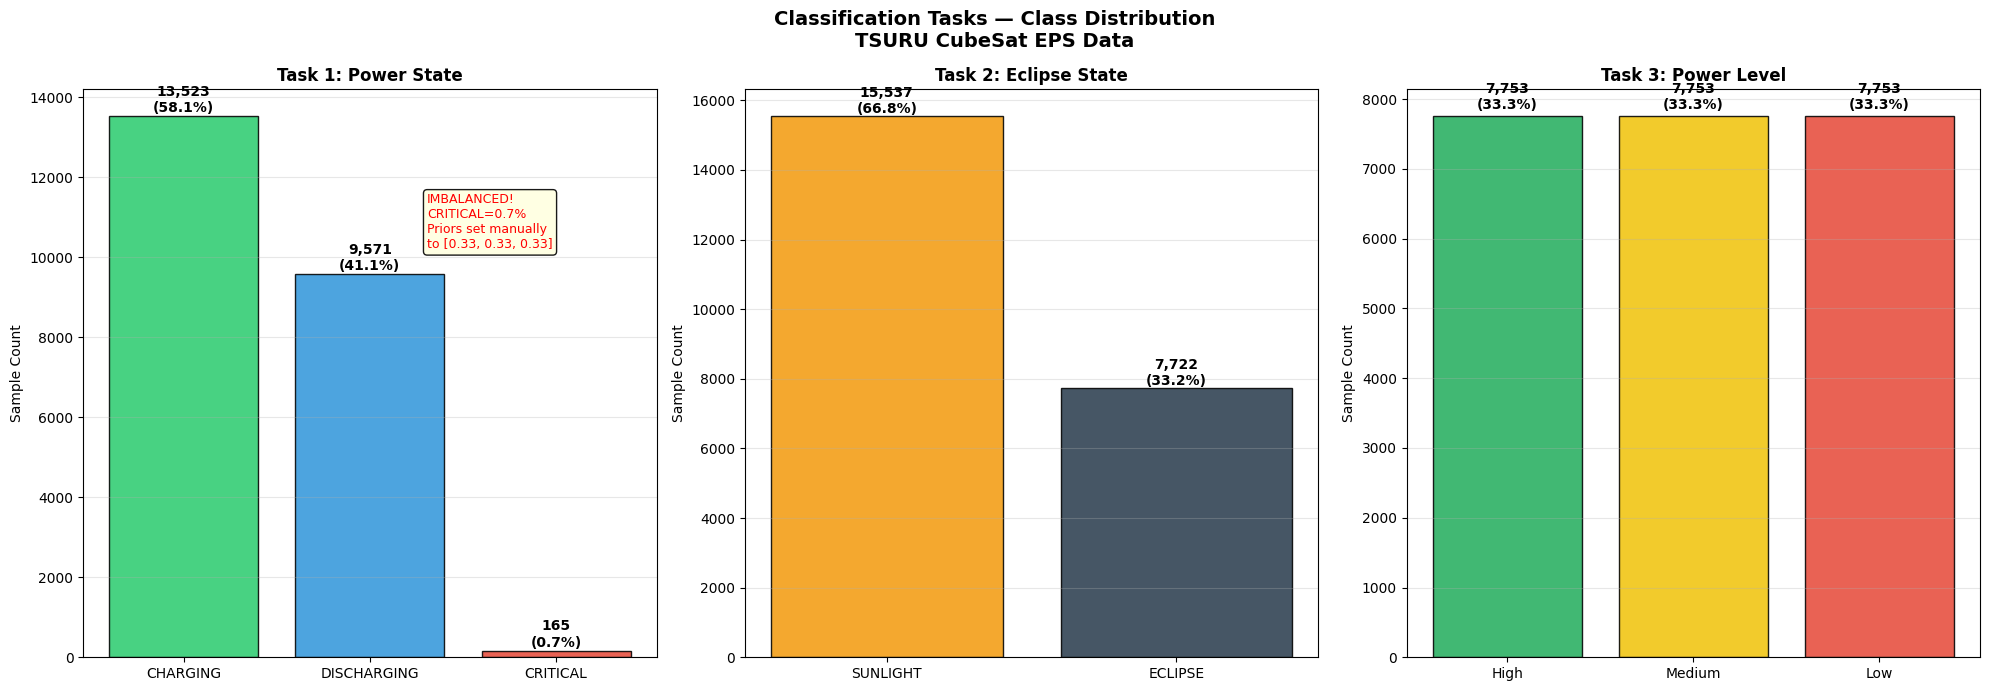

Class distribution plot saved.


In [3]:
# ============================================================
# SECTION 3: CLASS DISTRIBUTION EDA
# ------------------------------------------------------------
# NB handles imbalance differently from all previous models:
# No class_weight parameter — instead, class prior P(y) is
# learned directly from training data proportions.
# P(CRITICAL) = 165/23259 = 0.007 → NB will rarely predict it
# Fix: set priors manually to force equal weight per class
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Classification Tasks — Class Distribution\nTSURU CubeSat EPS Data',
             fontsize=14, fontweight='bold')

# Task 1
vc1   = df['Power_State'].value_counts()
cls1  = ['CHARGING', 'DISCHARGING', 'CRITICAL']
vals1 = [vc1.get(c, 0) for c in cls1]
bars1 = axes[0].bar(cls1, vals1,
                    color=['#2ecc71','#3498db','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[0].set_title('Task 1: Power State', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].text(0.60, 0.72,
             'IMBALANCED!\nCRITICAL=0.7%\nPriors set manually\nto [0.33, 0.33, 0.33]',
             transform=axes[0].transAxes, fontsize=9, color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Task 2
vc2   = df['Eclipse_State'].value_counts()
cls2  = ['SUNLIGHT', 'ECLIPSE']
vals2 = [vc2.get(c, 0) for c in cls2]
bars2 = axes[1].bar(cls2, vals2,
                    color=['#f39c12','#2c3e50'],
                    edgecolor='black', alpha=0.88)
axes[1].set_title('Task 2: Eclipse State', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Task 3
vc3   = df['Power_Level'].value_counts()
cls3  = ['High', 'Medium', 'Low']
vals3 = [vc3.get(c, 0) for c in cls3]
bars3 = axes[2].bar(cls3, vals3,
                    color=['#27ae60','#f1c40f','#e74c3c'],
                    edgecolor='black', alpha=0.88)
axes[2].set_title('Task 3: Power Level', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Sample Count')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('00_class_distribution.png', dpi=72, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

In [4]:
# ============================================================
# SECTION 4: BASE GaussianNB — DEFAULT PARAMETERS
# ------------------------------------------------------------
# GaussianNB assumes: P(xᵢ|y) = N(μ_iy, σ²_iy + var_smoothing)
# var_smoothing=1e-9 : tiny variance floor — default
# priors=None        : learned from data proportions
# priors=[1/3,1/3,1/3]: uniform — forces equal class weight
#
# Two variants tested:
#   Base A: priors=None    (data-driven — biased to CHARGING)
#   Base B: priors=uniform (equal weight — handles CRITICAL)
#
# ComplementNB: P(y|X) estimated from complement class
#   Equivalent to: learn what features indicate NOT-y
#   More robust for imbalanced data than standard NB
#   alpha=1.0 default: Laplace smoothing
# ============================================================

import time
results_before = {}

print("=" * 65)
print("BASE GaussianNB — var_smoothing=1e-9 | Two prior strategies")
print("=" * 65)
print()
print("Bayes Theorem:")
print("  P(y|X) = P(y) × ∏ P(xᵢ|y) / P(X)")
print("  log P(y|X) = log P(y) + Σ log P(xᵢ|y)")
print("  GaussianNB: log P(xᵢ|y) = -½[log(2πσ²) + (x-μ)²/σ²]")
print("=" * 65)

for task, d in datasets.items():
    classes_sorted = sorted(d['y_train'].unique())
    n_cls          = len(classes_sorted)
    uniform_prior  = [1/n_cls] * n_cls

    # Base A — data-driven priors
    t0     = time.time()
    modelA = GaussianNB(var_smoothing=1e-9, priors=None)
    modelA.fit(d['X_train'], d['y_train'])
    tA     = time.time() - t0

    # Base B — uniform priors (handles imbalance)
    t0     = time.time()
    modelB = GaussianNB(var_smoothing=1e-9, priors=uniform_prior)
    modelB.fit(d['X_train'], d['y_train'])
    tB     = time.time() - t0

    ypA = modelA.predict(d['X_test'])
    ypB = modelB.predict(d['X_test'])

    f1A = f1_score(d['y_test'], ypA, average='weighted', zero_division=0)
    f1B = f1_score(d['y_test'], ypB, average='weighted', zero_division=0)

    # Use uniform prior as base (better for imbalanced)
    results_before[task] = dict(
        model=modelB, y_pred=ypB,
        acc  =accuracy_score(d['y_test'], ypB),
        f1w  =f1_score(d['y_test'], ypB, average='weighted', zero_division=0),
        f1m  =f1_score(d['y_test'], ypB, average='macro',    zero_division=0))

    print(f"\nTask     : {task}")
    print(f"Classes  : {classes_sorted}")
    print(f"Train time (GaussianNB): {tA*1000:.2f} ms — "
          f"fastest possible (no iteration)")
    print(f"\n  [A] Data-driven priors:")
    print(f"      Learned priors: "
          f"{[f'{modelA.class_prior_[i]:.3f}' for i in range(n_cls)]}")
    print(f"      Accuracy={accuracy_score(d['y_test'],ypA):.4f} | "
          f"F1w={f1A:.4f}")
    print(f"\n  [B] Uniform priors (imbalance correction):")
    print(f"      Set priors: {[f'{p:.3f}' for p in uniform_prior]}")
    print(f"      Accuracy={accuracy_score(d['y_test'],ypB):.4f} | "
          f"F1w={f1B:.4f}")
    print(f"\nClassification Report (Uniform Prior):")
    print(classification_report(d['y_test'], ypB, zero_division=0))

BASE GaussianNB — var_smoothing=1e-9 | Two prior strategies

Bayes Theorem:
  P(y|X) = P(y) × ∏ P(xᵢ|y) / P(X)
  log P(y|X) = log P(y) + Σ log P(xᵢ|y)
  GaussianNB: log P(xᵢ|y) = -½[log(2πσ²) + (x-μ)²/σ²]

Task     : Power_State
Classes  : ['CHARGING', 'CRITICAL', 'DISCHARGING']
Train time (GaussianNB): 32.99 ms — fastest possible (no iteration)

  [A] Data-driven priors:
      Learned priors: ['0.597', '0.007', '0.397']
      Accuracy=0.8044 | F1w=0.8239

  [B] Uniform priors (imbalance correction):
      Set priors: ['0.333', '0.333', '0.333']
      Accuracy=0.7890 | F1w=0.8140

Classification Report (Uniform Prior):
              precision    recall  f1-score   support

    CHARGING       0.87      0.89      0.88      1957
    CRITICAL       0.06      0.49      0.10        39
 DISCHARGING       0.84      0.69      0.76      1880

    accuracy                           0.79      3876
   macro avg       0.59      0.69      0.58      3876
weighted avg       0.85      0.79      0.81    

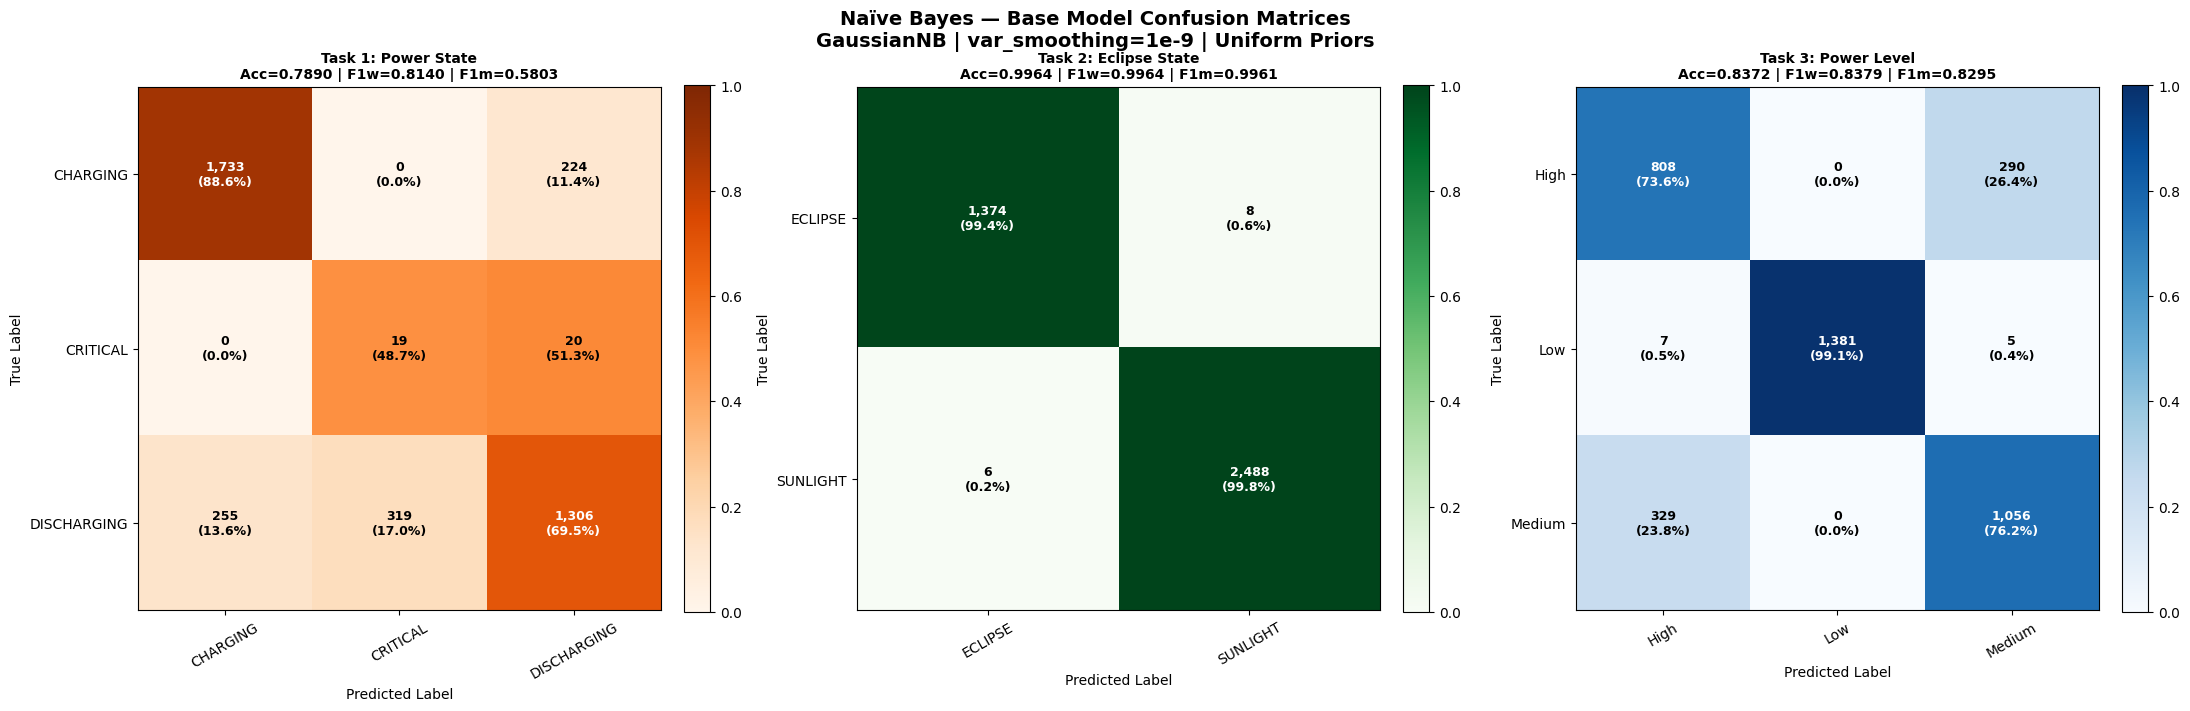

Base model confusion matrices saved.


In [5]:
# ============================================================
# SECTION 5: BASE MODEL CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Naïve Bayes — Base Model Confusion Matrices\n'
             'GaussianNB | var_smoothing=1e-9 | Uniform Priors',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']

for ax, (task, d), cmap, title in zip(
        axes, datasets.items(), cmaps, titles):
    r       = results_before[task]
    classes = r['model'].classes_
    cm      = confusion_matrix(d['y_test'], r['y_pred'], labels=classes)
    cm_n    = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=30)
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i,
                    f'{cm[i,j]:,}\n({cm_n[i,j]:.1%})',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if cm_n[i,j] > 0.55 else 'black')

    ax.set_title(
        f'{title}\nAcc={r["acc"]:.4f} | '
        f'F1w={r["f1w"]:.4f} | F1m={r["f1m"]:.4f}',
        fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('01_base_confusion.png', dpi=72, bbox_inches='tight')
plt.show()
print("Base model confusion matrices saved.")

In [6]:
# ============================================================
# SECTION 6: UNIQUE ANALYSIS — NB SPECIFIC
# Part A: var_smoothing sweep — fundamental tuning parameter
#         Adds ε×max(σ²) to every class variance
#         Small → overfit to training likelihoods
#         Large → smooth toward uniform likelihood
# Part B: NB Variant comparison
#         GaussianNB vs ComplementNB (alpha sweep)
#         ComplementNB better for imbalanced — learns
#         from complement class statistics
# Part C: Prior probability effect
#         Data-driven vs uniform vs custom priors
#         Directly controls CRITICAL detection threshold
# Part D: Feature likelihood distributions (NB UNIQUE)
#         For each class, plot learned Gaussian N(μ,σ²)
#         per feature — this IS the NB model visualised
# ============================================================

print("Running unique analyses...")

# Part A: var_smoothing sweep for GaussianNB
vs_range  = np.logspace(-12, 0, 30)
vs_results = {task: {'train_f1':[], 'test_f1':[], 'test_acc':[]}
              for task in datasets}

for task, d in datasets.items():
    classes_sorted = sorted(d['y_train'].unique())
    n_cls          = len(classes_sorted)
    uniform_prior  = [1/n_cls] * n_cls
    for vs in vs_range:
        m = GaussianNB(var_smoothing=vs, priors=uniform_prior)
        m.fit(d['X_train'], d['y_train'])
        yp = m.predict(d['X_test'])
        vs_results[task]['train_f1'].append(
            f1_score(d['y_train'], m.predict(d['X_train']),
                     average='weighted', zero_division=0))
        vs_results[task]['test_f1'].append(
            f1_score(yp, d['y_test'],
                     average='weighted', zero_division=0))
        vs_results[task]['test_acc'].append(
            accuracy_score(d['y_test'], yp))
    print(f"  var_smoothing sweep done: {task}")

# Part B: NB Variant comparison
# GaussianNB at best var_smoothing vs ComplementNB at best alpha
alpha_range = np.logspace(-3, 2, 20)
cnb_results = {task: {'alpha':[], 'test_f1':[], 'test_acc':[]}
               for task in datasets}

for task, d in datasets_cnb.items():
    for alpha in alpha_range:
        m  = ComplementNB(alpha=alpha)
        m.fit(d['X_train'], d['y_train'])
        yp = m.predict(d['X_test'])
        cnb_results[task]['alpha'].append(alpha)
        cnb_results[task]['test_f1'].append(
            f1_score(yp, d['y_test'],
                     average='weighted', zero_division=0))
        cnb_results[task]['test_acc'].append(
            accuracy_score(d['y_test'], yp))
    print(f"  ComplementNB sweep done: {task}")

# Part C: Prior probability effect
# Three strategies: data-driven, uniform, CRITICAL-boosted
prior_configs = {}
for task, d in datasets.items():
    classes_sorted = sorted(d['y_train'].unique())
    n_cls          = len(classes_sorted)
    data_prior     = [float(np.mean(d['y_train'] == c))
                      for c in classes_sorted]

    if 'CRITICAL' in classes_sorted and n_cls == 3:
        # boost CRITICAL
        crit_idx    = classes_sorted.index('CRITICAL')
        # Initialize boost_prior with smaller values for other classes
        boost_prior = [0.15] * n_cls
        boost_prior[crit_idx] = 0.70  # Assign higher prior to CRITICAL
        boost_prior = [p/sum(boost_prior) for p in boost_prior]
        configs = [
            ('Data-driven', data_prior),
            ('Uniform',     [1/n_cls]*n_cls),
            ('CRITICAL-boost', boost_prior)
        ]
    else:
        configs = [
            ('Data-driven', data_prior),
            ('Uniform',     [1/n_cls]*n_cls),
        ]

    prior_configs[task] = []
    for lbl, prior in configs:
        m  = GaussianNB(var_smoothing=1e-9, priors=prior)
        m.fit(d['X_train'], d['y_train'])
        yp = m.predict(d['X_test'])
        prior_configs[task].append(dict(
            label=lbl,
            prior=prior,
            acc  =accuracy_score(d['y_test'], yp),
            f1w  =f1_score(yp, d['y_test'],
                           average='weighted', zero_division=0),
            f1m  =f1_score(yp, d['y_test'],
                           average='macro',    zero_division=0),
            report=classification_report(d['y_test'], yp,
                                         zero_division=0)
        ))
    print(f"  Prior analysis done: {task}")

# Part D: Learned likelihood parameters (μ, σ per class)
# Fit best GaussianNB and extract theta_ (means) and var_ (variances)
likelihood_params = {}
for task, d in datasets.items():
    classes_sorted = sorted(d['y_train'].unique())
    n_cls          = len(classes_sorted)
    uniform_prior  = [1/n_cls] * n_cls
    best_vs_idx    = int(np.argmax(vs_results[task]['test_f1']))
    best_vs        = vs_range[best_vs_idx]
    m = GaussianNB(var_smoothing=best_vs, priors=uniform_prior)
    m.fit(d['X_train'], d['y_train'])
    likelihood_params[task] = dict(
        model    =m,
        classes  =list(m.classes_),
        theta    =m.theta_,      # shape: (n_classes, n_features) — means
        var      =m.var_,        # shape: (n_classes, n_features) — variances
        features =d['features'],
        best_vs  =best_vs
    )
    print(f"  Likelihood params extracted: {task}")

print("\nAll unique analyses complete.")

Running unique analyses...
  var_smoothing sweep done: Power_State
  var_smoothing sweep done: Eclipse_State
  var_smoothing sweep done: Power_Level
  ComplementNB sweep done: Power_State
  ComplementNB sweep done: Eclipse_State
  ComplementNB sweep done: Power_Level
  Prior analysis done: Power_State
  Prior analysis done: Eclipse_State
  Prior analysis done: Power_Level
  Likelihood params extracted: Power_State
  Likelihood params extracted: Eclipse_State
  Likelihood params extracted: Power_Level

All unique analyses complete.


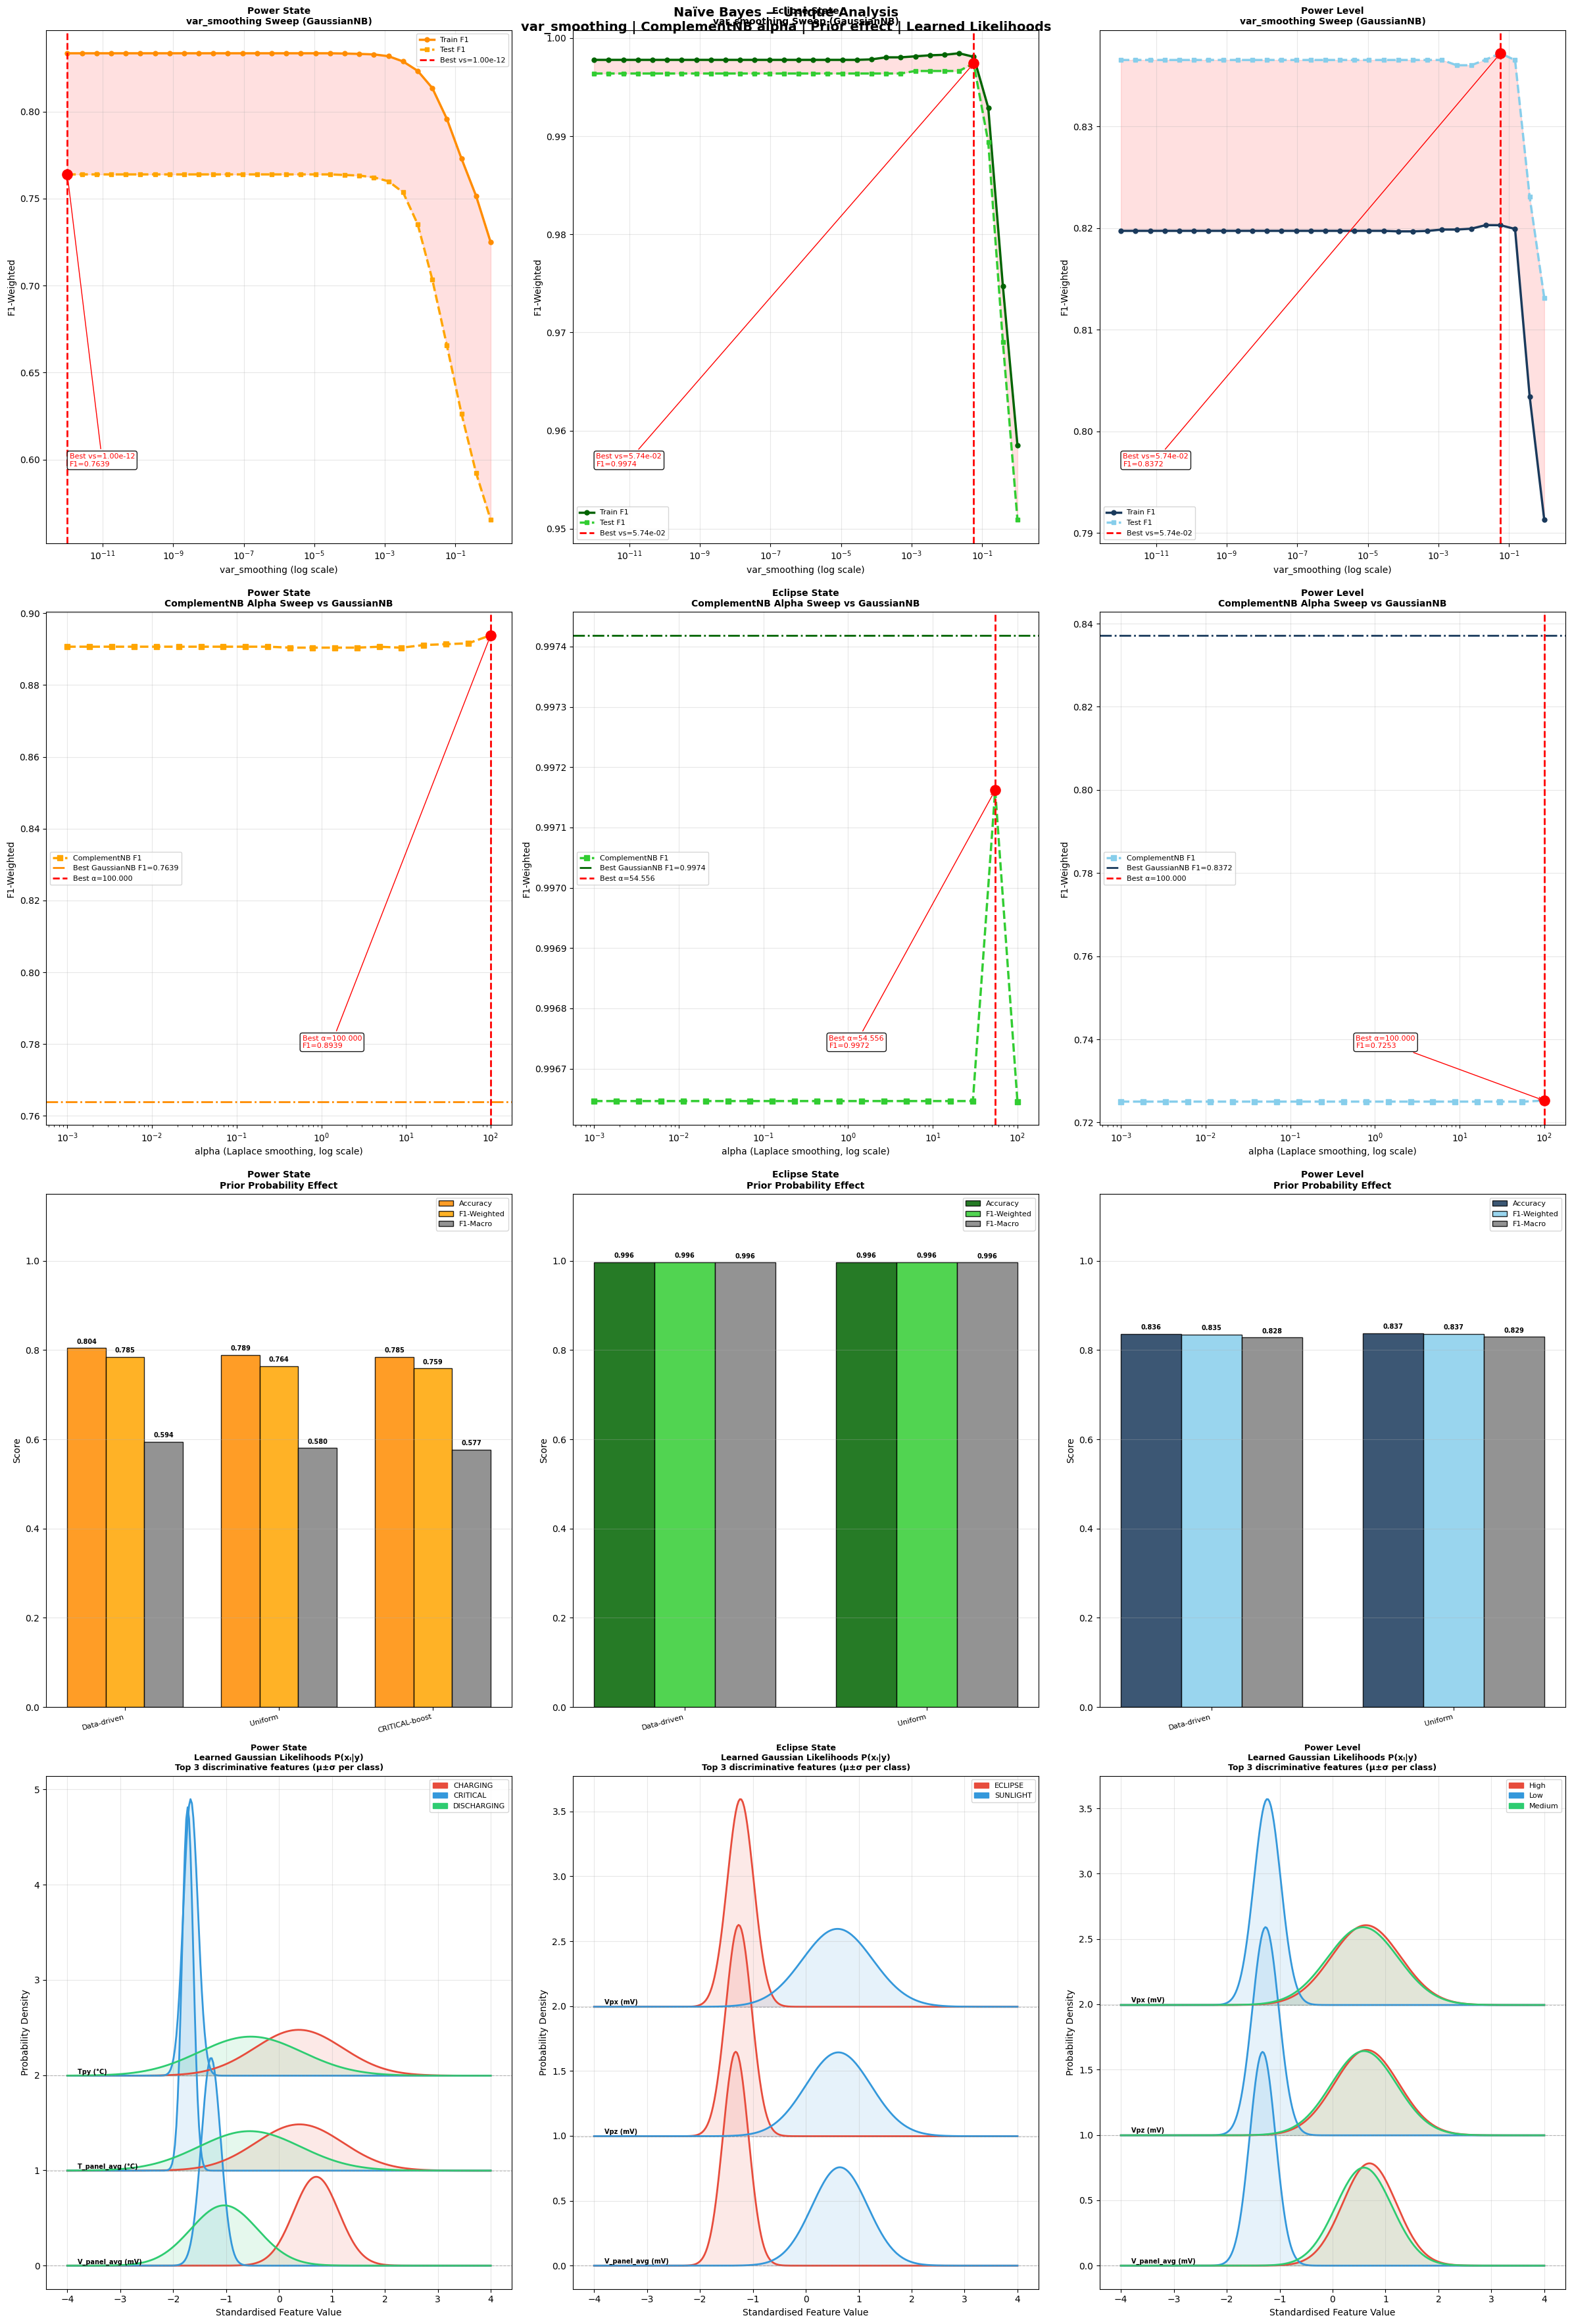

Unique analysis plots saved.


In [7]:
# ============================================================
# SECTION 6 CONT: UNIQUE ANALYSIS PLOTS (4×3 grid)
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(24, 36))
fig.suptitle('Naïve Bayes — Unique Analysis\n'
             'var_smoothing | ComplementNB alpha | '
             'Prior effect | Learned Likelihoods',
             fontsize=14, fontweight='bold')

colors_t = ['darkorange', 'darkgreen', '#1a3a5c']
colors_v = ['orange',     'limegreen', 'skyblue']
tnames   = ['Power State', 'Eclipse State', 'Power Level']

for col, (task, ct, cv, tn) in enumerate(zip(
        datasets.keys(), colors_t, colors_v, tnames)):

    # ── Row 0: var_smoothing sweep ──────────────────────────
    ax       = axes[0, col]
    tr_f1    = vs_results[task]['train_f1']
    te_f1    = vs_results[task]['test_f1']
    best_idx = int(np.argmax(te_f1))
    best_vs  = vs_range[best_idx]
    best_f1  = max(te_f1)

    ax.semilogx(vs_range, tr_f1, 'o-', color=ct,
                lw=2.5, ms=5, label='Train F1')
    ax.semilogx(vs_range, te_f1, 's--', color=cv,
                lw=2.5, ms=5, label='Test F1')
    ax.fill_between(vs_range, tr_f1, te_f1,
                    alpha=0.12, color='red')
    ax.axvline(best_vs, color='red', ls='--', lw=2,
               label=f'Best vs={best_vs:.2e}')
    ax.scatter([best_vs], [best_f1],
               color='red', s=120, zorder=5)
    ax.annotate(
        f'Best vs={best_vs:.2e}\nF1={best_f1:.4f}',
        xy=(best_vs, best_f1),
        xytext=(0.05, 0.15), textcoords='axes fraction',
        fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_title(f'{tn}\nvar_smoothing Sweep (GaussianNB)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('var_smoothing (log scale)')
    ax.set_ylabel('F1-Weighted')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Row 1: ComplementNB alpha sweep ────────────────────
    ax1      = axes[1, col]
    cnb_f1   = cnb_results[task]['test_f1']
    alphas   = cnb_results[task]['alpha']
    best_ai  = int(np.argmax(cnb_f1))
    best_a   = alphas[best_ai]
    best_af1 = max(cnb_f1)

    # Best GaussianNB F1 as reference line
    gnb_best_f1 = max(vs_results[task]['test_f1'])

    ax1.semilogx(alphas, cnb_f1, 's--', color=cv,
                 lw=2.5, ms=6, label='ComplementNB F1')
    ax1.axhline(gnb_best_f1, color=ct, ls='-.',
                lw=2, label=f'Best GaussianNB F1={gnb_best_f1:.4f}')
    ax1.axvline(best_a, color='red', ls='--', lw=2,
                label=f'Best α={best_a:.3f}')
    ax1.scatter([best_a], [best_af1],
                color='red', s=120, zorder=5)
    ax1.annotate(
        f'Best α={best_a:.3f}\nF1={best_af1:.4f}',
        xy=(best_a, best_af1),
        xytext=(0.55, 0.15), textcoords='axes fraction',
        fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='red'))
    ax1.set_title(f'{tn}\nComplementNB Alpha Sweep vs GaussianNB',
                  fontweight='bold', fontsize=10)
    ax1.set_xlabel('alpha (Laplace smoothing, log scale)')
    ax1.set_ylabel('F1-Weighted')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # ── Row 2: Prior probability effect ────────────────────
    ax2    = axes[2, col]
    pdata  = prior_configs[task]
    lbls   = [p['label'] for p in pdata]
    accs   = [p['acc']   for p in pdata]
    f1ws   = [p['f1w']   for p in pdata]
    f1ms   = [p['f1m']   for p in pdata]
    x      = np.arange(len(lbls))
    w      = 0.25

    ax2.bar(x-w, accs, w, label='Accuracy',
            color=ct, edgecolor='black', alpha=0.85)
    ax2.bar(x,   f1ws, w, label='F1-Weighted',
            color=cv, edgecolor='black', alpha=0.85)
    ax2.bar(x+w, f1ms, w, label='F1-Macro',
            color='gray', edgecolor='black', alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(lbls, rotation=15, ha='right', fontsize=8)
    ax2.set_title(f'{tn}\nPrior Probability Effect',
                  fontweight='bold', fontsize=10)
    ax2.set_ylabel('Score')
    ax2.set_ylim([0, 1.15])
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis='y')
    for xi, (a, f, m) in enumerate(zip(accs, f1ws, f1ms)):
        ax2.text(xi-w, a+0.01, f'{a:.3f}', ha='center',
                 fontsize=7, fontweight='bold')
        ax2.text(xi,   f+0.01, f'{f:.3f}', ha='center',
                 fontsize=7, fontweight='bold')
        ax2.text(xi+w, m+0.01, f'{m:.3f}', ha='center',
                 fontsize=7, fontweight='bold')

    # ── Row 3: Learned Likelihood Distributions ────────────
    # Show top 3 most discriminative features: μ±σ per class
    ax3   = axes[3, col]
    lp    = likelihood_params[task]
    feats = lp['features']
    theta = lp['theta']   # (n_classes, n_features)
    var   = lp['var']     # (n_classes, n_features)
    classes = lp['classes']

    # Pick top 3 features by inter-class variance of means
    inter_var  = np.var(theta, axis=0)
    top3_idx   = np.argsort(inter_var)[::-1][:3]
    top3_feats = [feats[i] for i in top3_idx]

    cls_colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']
    x_range    = np.linspace(-4, 4, 300)

    for fi, (feat_idx, fname) in enumerate(
            zip(top3_idx, top3_feats)):
        ax3_sub = ax3 if fi == 0 else None
        for ci, (cls, clr) in enumerate(zip(
                classes, cls_colors[:len(classes)])):
            mu  = theta[ci, feat_idx]
            sig = np.sqrt(var[ci, feat_idx])
            pdf = norm.pdf(x_range, mu, sig)
            # Offset curves vertically by feature index
            offset = fi * max([norm.pdf(0,0,1)]) * 2.5
            ax3.plot(x_range, pdf + offset, color=clr,
                     lw=2, label=cls if fi == 0 else '')
            ax3.fill_between(x_range, offset,
                             pdf + offset, alpha=0.12, color=clr)
        ax3.axhline(fi * norm.pdf(0,0,1)*2.5,
                    color='gray', ls='--', lw=0.8, alpha=0.5)
        ax3.text(-3.8, fi*norm.pdf(0,0,1)*2.5 + 0.02,
                 fname[:18], fontsize=7, fontweight='bold')

    ax3.set_title(f'{tn}\nLearned Gaussian Likelihoods P(xᵢ|y)\n'
                  f'Top 3 discriminative features (μ±σ per class)',
                  fontweight='bold', fontsize=9)
    ax3.set_xlabel('Standardised Feature Value')
    ax3.set_ylabel('Probability Density')
    handles = [mpatches.Patch(color=cls_colors[i], label=cls)
               for i, cls in enumerate(classes)]
    ax3.legend(handles=handles, fontsize=8, loc='upper right')
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_unique_analysis.png', dpi=72, bbox_inches='tight')
plt.show()
print("Unique analysis plots saved.")

In [8]:
# ============================================================
# SECTION 7: HYPERPARAMETER TUNING
# ============================================================

from sklearn.metrics import make_scorer

# FIX 1: Custom safe scorer — returns 0 instead of nan
def safe_f1_macro(y_true, y_pred):
    score = f1_score(y_true, y_pred,
                     average='macro', zero_division=0)
    return 0.0 if np.isnan(score) else score

safe_scorer = make_scorer(safe_f1_macro)

results_after = {}

print("=" * 65)
print("TUNING — GaussianNB + ComplementNB")
print("GaussianNB  : var_smoothing best from log sweep")
print("ComplementNB: alpha best from log sweep")
print("Scoring     : safe f1_macro (nan→0) — avoids nan")
print("CV          : 5-fold TimeSeriesSplit")
print("=" * 65)

for task, d in datasets.items():
    classes_sorted = sorted(d['y_train'].unique())
    n_cls          = len(classes_sorted)
    uniform_prior  = [1/n_cls]*n_cls

    # ── Best GaussianNB from sweep ──────────────────────────
    best_vs_idx = int(np.argmax(vs_results[task]['test_f1']))
    best_vs     = vs_range[best_vs_idx]

    gnb_best = GaussianNB(var_smoothing=best_vs,
                          priors=uniform_prior)
    gnb_best.fit(d['X_train'], d['y_train'])
    yp_gnb   = gnb_best.predict(d['X_test'])

    cv_gnb = cross_val_score(
        GaussianNB(var_smoothing=best_vs, priors=uniform_prior),
        d['X_train'], d['y_train'],
        cv=tscv, scoring=safe_scorer, n_jobs=-1)

    f1_gnb = f1_score(d['y_test'], yp_gnb,
                      average='weighted', zero_division=0)
    fm_gnb = f1_score(d['y_test'], yp_gnb,
                      average='macro',    zero_division=0)

    # ── Best ComplementNB from sweep ────────────────────────
    best_ai  = int(np.argmax(cnb_results[task]['test_f1']))
    best_a   = cnb_results[task]['alpha'][best_ai]
    d_cnb    = datasets_cnb[task]

    cnb_best = ComplementNB(alpha=best_a)
    cnb_best.fit(d_cnb['X_train'], d_cnb['y_train'])
    yp_cnb   = cnb_best.predict(d_cnb['X_test'])

    cv_cnb = cross_val_score(
        ComplementNB(alpha=best_a),
        d_cnb['X_train'], d_cnb['y_train'],
        cv=tscv, scoring=safe_scorer, n_jobs=-1)

    f1_cnb = f1_score(d_cnb['y_test'], yp_cnb,
                      average='weighted', zero_division=0)
    fm_cnb = f1_score(d_cnb['y_test'], yp_cnb,
                      average='macro',    zero_division=0)

    # FIX 2: np.nanmean / np.nanstd instead of .mean() / .std()
    gnb_cv_mean = float(np.nanmean(cv_gnb))
    gnb_cv_std  = float(np.nanstd(cv_gnb))
    cnb_cv_mean = float(np.nanmean(cv_cnb))
    cnb_cv_std  = float(np.nanstd(cv_cnb))

    # ── Select better by CV macro F1 ────────────────────────
    if gnb_cv_mean >= cnb_cv_mean:
        chosen_model  = gnb_best
        chosen_pred   = yp_gnb
        chosen_label  = f'GaussianNB(vs={best_vs:.2e})'
        chosen_params = {'variant'      : 'GaussianNB',
                         'var_smoothing': best_vs,
                         'priors'       : 'uniform'}
        chosen_cv_mean= gnb_cv_mean
        chosen_cv_std = gnb_cv_std
        chosen_cv     = cv_gnb
        chosen_f1w    = f1_gnb
        chosen_f1m    = fm_gnb
        chosen_acc    = accuracy_score(d['y_test'], yp_gnb)
        chosen_Xte    = d['X_test']
        chosen_yte    = d['y_test']
    else:
        chosen_model  = cnb_best
        chosen_pred   = yp_cnb
        chosen_label  = f'ComplementNB(α={best_a:.3f})'
        chosen_params = {'variant': 'ComplementNB',
                         'alpha'  : best_a}
        chosen_cv_mean= cnb_cv_mean
        chosen_cv_std = cnb_cv_std
        chosen_cv     = cv_cnb
        chosen_f1w    = f1_cnb
        chosen_f1m    = fm_cnb
        chosen_acc    = accuracy_score(d_cnb['y_test'], yp_cnb)
        chosen_Xte    = d_cnb['X_test']
        chosen_yte    = d_cnb['y_test']

    results_after[task] = dict(
        model        = chosen_model,
        params       = chosen_params,
        y_pred       = chosen_pred,
        acc          = chosen_acc,
        f1w          = chosen_f1w,
        f1m          = chosen_f1m,
        cv           = chosen_cv,
        cv_mean      = chosen_cv_mean,
        cv_std       = chosen_cv_std,
        X_test       = chosen_Xte,
        y_test       = chosen_yte,
        label        = chosen_label,
        gnb_f1w      = f1_gnb,  gnb_f1m = fm_gnb,
        gnb_cv_mean  = gnb_cv_mean, gnb_cv_std = gnb_cv_std,
        cnb_f1w      = f1_cnb,  cnb_f1m = fm_cnb,
        cnb_cv_mean  = cnb_cv_mean, cnb_cv_std = cnb_cv_std)

    print(f"\nTask        : {task}")
    print(f"\n  GaussianNB  (vs={best_vs:.2e}, uniform priors):")
    print(f"    F1w={f1_gnb:.4f} | F1m={fm_gnb:.4f} | "
          f"CV macro={gnb_cv_mean:.4f}±{gnb_cv_std:.4f}")
    print(f"\n  ComplementNB (α={best_a:.3f}):")
    print(f"    F1w={f1_cnb:.4f} | F1m={fm_cnb:.4f} | "
          f"CV macro={cnb_cv_mean:.4f}±{cnb_cv_std:.4f}")
    print(f"\n   Selected : {chosen_label}")
    print(f"     Accuracy = {chosen_acc:.4f}")
    print(f"     F1w      = {chosen_f1w:.4f}")
    print(f"     F1m      = {chosen_f1m:.4f}")
    print(f"\nClassification Report ({chosen_label}):")
    print(classification_report(chosen_yte, chosen_pred,
                                 zero_division=0))

TUNING — GaussianNB + ComplementNB
GaussianNB  : var_smoothing best from log sweep
ComplementNB: alpha best from log sweep
Scoring     : safe f1_macro (nan→0) — avoids nan
CV          : 5-fold TimeSeriesSplit

Task        : Power_State

  GaussianNB  (vs=1.00e-12, uniform priors):
    F1w=0.8140 | F1m=0.5803 | CV macro=0.5749±0.0607

  ComplementNB (α=100.000):
    F1w=0.8817 | F1m=0.5935 | CV macro=0.6070±0.0231

   Selected : ComplementNB(α=100.000)
     Accuracy = 0.8878
     F1w      = 0.8817
     F1m      = 0.5935

Classification Report (ComplementNB(α=100.000)):
              precision    recall  f1-score   support

    CHARGING       0.83      1.00      0.91      1957
    CRITICAL       0.00      0.00      0.00        39
 DISCHARGING       0.97      0.79      0.87      1880

    accuracy                           0.89      3876
   macro avg       0.60      0.60      0.59      3876
weighted avg       0.89      0.89      0.88      3876


Task        : Eclipse_State

  GaussianNB  

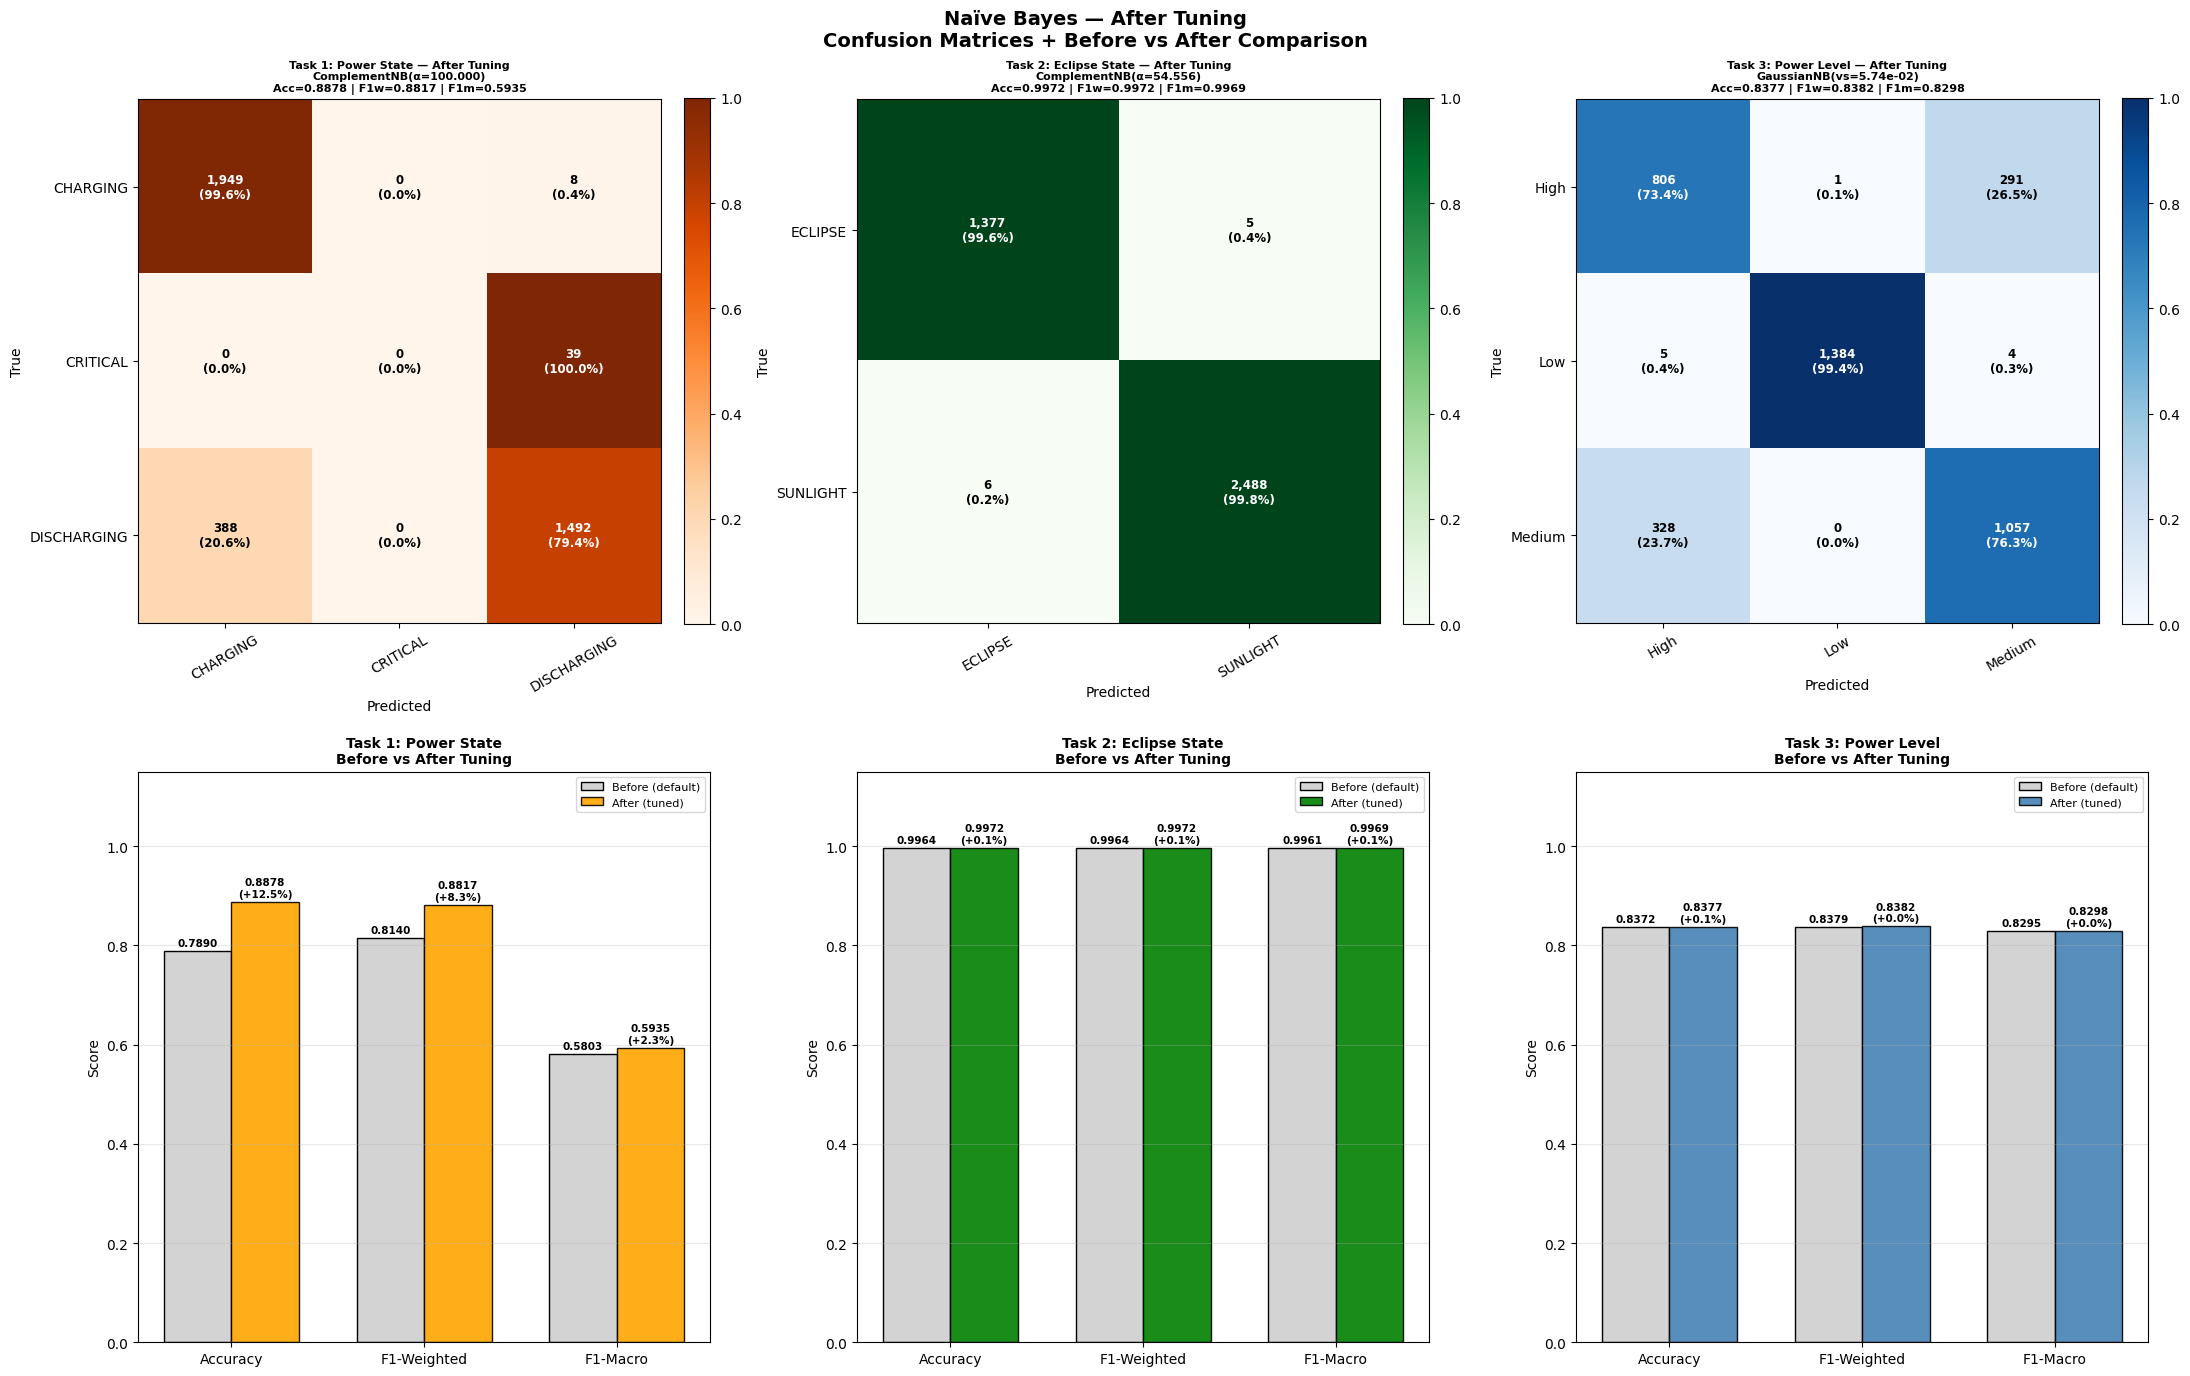

After tuning plots saved.


In [9]:
# ============================================================
# SECTION 8: AFTER TUNING — CONFUSION MATRICES + COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Naïve Bayes — After Tuning\n'
             'Confusion Matrices + Before vs After Comparison',
             fontsize=14, fontweight='bold')

cmaps  = ['Oranges', 'Greens', 'Blues']
titles = ['Task 1: Power State',
          'Task 2: Eclipse State',
          'Task 3: Power Level']
colors = ['orange', 'green', 'steelblue']

# Row 1: After tuning confusion matrices
for col, (task, cmap, title) in enumerate(zip(
        datasets.keys(), cmaps, titles)):
    r       = results_after[task]
    yte     = r['y_test']
    yp      = r['y_pred']
    classes = r['model'].classes_
    cm      = confusion_matrix(yte, yp, labels=classes)
    cm_n    = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = axes[0, col].imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)
    axes[0, col].set_xticks(range(len(classes)))
    axes[0, col].set_xticklabels(classes, rotation=30)
    axes[0, col].set_yticks(range(len(classes)))
    axes[0, col].set_yticklabels(classes)
    axes[0, col].set_xlabel('Predicted')
    axes[0, col].set_ylabel('True')

    for i in range(len(classes)):
        for j in range(len(classes)):
            axes[0, col].text(
                j, i,
                f'{cm[i,j]:,}\n({cm_n[i,j]:.1%})',
                ha='center', va='center',
                fontsize=8.5, fontweight='bold',
                color='white' if cm_n[i,j] > 0.55 else 'black')

    axes[0, col].set_title(
        f'{title} — After Tuning\n'
        f'{r["label"]}\n'
        f'Acc={r["acc"]:.4f} | '
        f'F1w={r["f1w"]:.4f} | F1m={r["f1m"]:.4f}',
        fontweight='bold', fontsize=8)

# Row 2: Before vs After bars
for col, (task, clr, title) in enumerate(zip(
        datasets.keys(), colors, titles)):
    ax    = axes[1, col]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1w = results_before[task]['f1w']
    a_f1w = results_after[task]['f1w']
    b_f1m = results_before[task]['f1m']
    a_f1m = results_after[task]['f1m']

    x = np.arange(3)
    w = 0.35
    ax.bar(x-w/2, [b_acc, b_f1w, b_f1m], w,
           label='Before (default)',
           color='lightgray', edgecolor='black')
    ax.bar(x+w/2, [a_acc, a_f1w, a_f1m], w,
           label=f'After (tuned)',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy','F1-Weighted','F1-Macro'])
    ax.set_title(f'{title}\nBefore vs After Tuning',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.15])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    for bv, av, xi in zip([b_acc,b_f1w,b_f1m],
                           [a_acc,a_f1w,a_f1m], x):
        delta = (av-bv)/max(bv,1e-9)*100
        ax.text(xi-w/2, bv+0.01, f'{bv:.4f}',
                ha='center', fontsize=7.5, fontweight='bold')
        ax.text(xi+w/2, av+0.01,
                f'{av:.4f}\n({delta:+.1f}%)',
                ha='center', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig('03_after_tuning.png', dpi=72, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

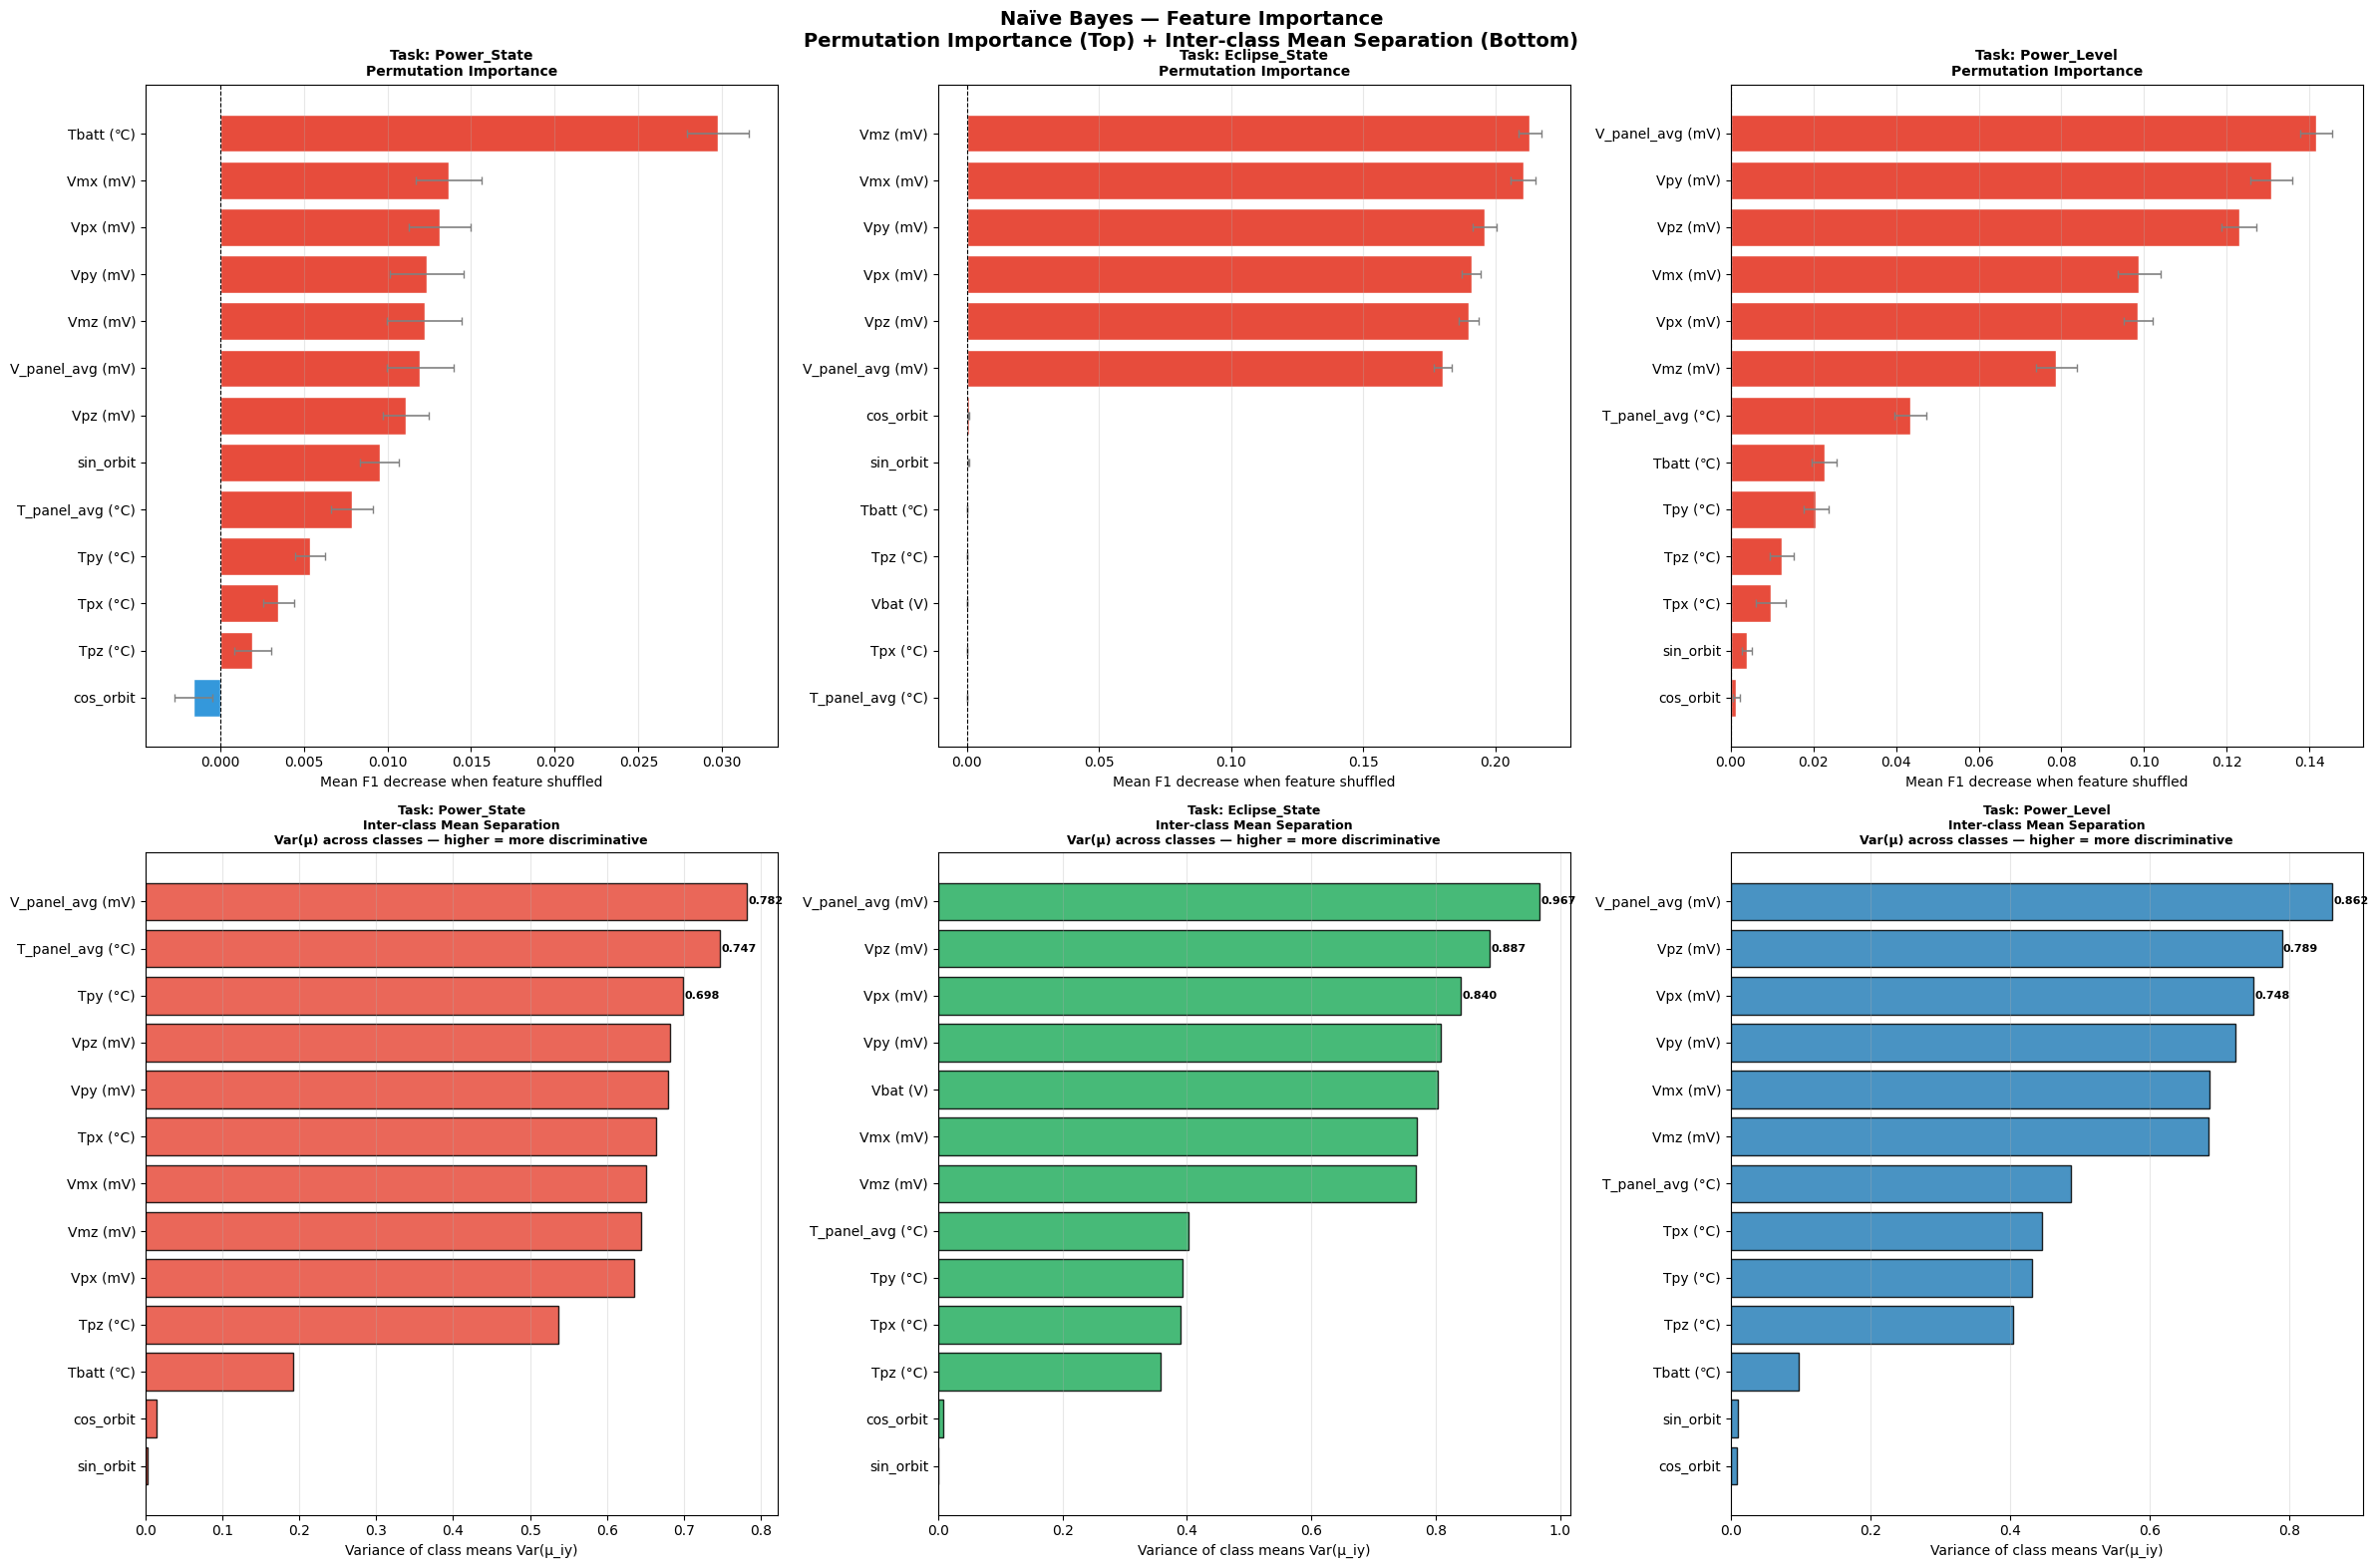

Feature importance plots saved.


In [10]:
# ============================================================
# SECTION 9: PERMUTATION FEATURE IMPORTANCE
# ------------------------------------------------------------
# GaussianNB has no built-in feature_importances_ attribute.
# Permutation importance: shuffle one feature, measure F1 drop.
# Features with large mean drop are most important.
# NB UNIQUE: We can ALSO directly examine learned parameters:
#   theta_ (μ per class) — features where classes have
#   very different means are more discriminative
#   var_ (σ² per class) — narrow distributions = high certainty
# Both shown for complete NB-specific analysis.
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Naïve Bayes — Feature Importance\n'
             'Permutation Importance (Top) + '
             'Inter-class Mean Separation (Bottom)',
             fontsize=14, fontweight='bold')

bar_colors = ['#e74c3c', '#27ae60', '#2980b9']

for col, (task, d, clr) in enumerate(zip(
        datasets.keys(), datasets.values(), bar_colors)):
    model   = results_after[task]['model']
    feats   = d['features']
    Xte     = results_after[task]['X_test']
    yte     = results_after[task]['y_test']

    # Permutation importance
    perm = permutation_importance(
        model, Xte, yte,
        n_repeats=15, scoring='f1_weighted',
        random_state=SEED, n_jobs=-1)

    sorted_i = np.argsort(perm.importances_mean)
    top_n    = min(13, len(feats))
    top_i    = sorted_i[-top_n:]

    bar_cols = ['#e74c3c' if perm.importances_mean[i] >= 0
                else '#3498db' for i in top_i]
    ax = axes[0, col]
    ax.barh([feats[i] for i in top_i],
            perm.importances_mean[top_i],
            xerr=perm.importances_std[top_i],
            color=bar_cols, edgecolor='white',
            error_kw=dict(ecolor='gray', capsize=3, elinewidth=1.2))
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'Task: {task}\nPermutation Importance',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean F1 decrease when feature shuffled')
    ax.grid(True, alpha=0.3, axis='x')

    # Inter-class mean separation (NB unique)
    # Use GaussianNB theta_ (means) if available
    lp = likelihood_params[task]
    theta   = lp['theta']      # (n_classes, n_features)
    classes = lp['classes']

    # Inter-class variance of means per feature
    inter_var  = np.var(theta, axis=0)
    sort_iv    = np.argsort(inter_var)[::-1][:top_n]

    ax2 = axes[1, col]
    ax2.barh([feats[i] for i in sort_iv[::-1]],
             inter_var[sort_iv[::-1]],
             color=clr, edgecolor='black', alpha=0.85)
    ax2.set_title(
        f'Task: {task}\nInter-class Mean Separation\n'
        f'Var(μ) across classes — higher = more discriminative',
        fontweight='bold', fontsize=9)
    ax2.set_xlabel('Variance of class means Var(μ_iy)')
    ax2.grid(True, alpha=0.3, axis='x')

    # Label top 3
    for i in range(min(3, len(sort_iv))):
        idx = sort_iv[i]
        ax2.text(inter_var[idx]+0.002,
                 top_n-1-i,
                 f'{inter_var[idx]:.3f}',
                 va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=72, bbox_inches='tight')
plt.show()
print("Feature importance plots saved.")

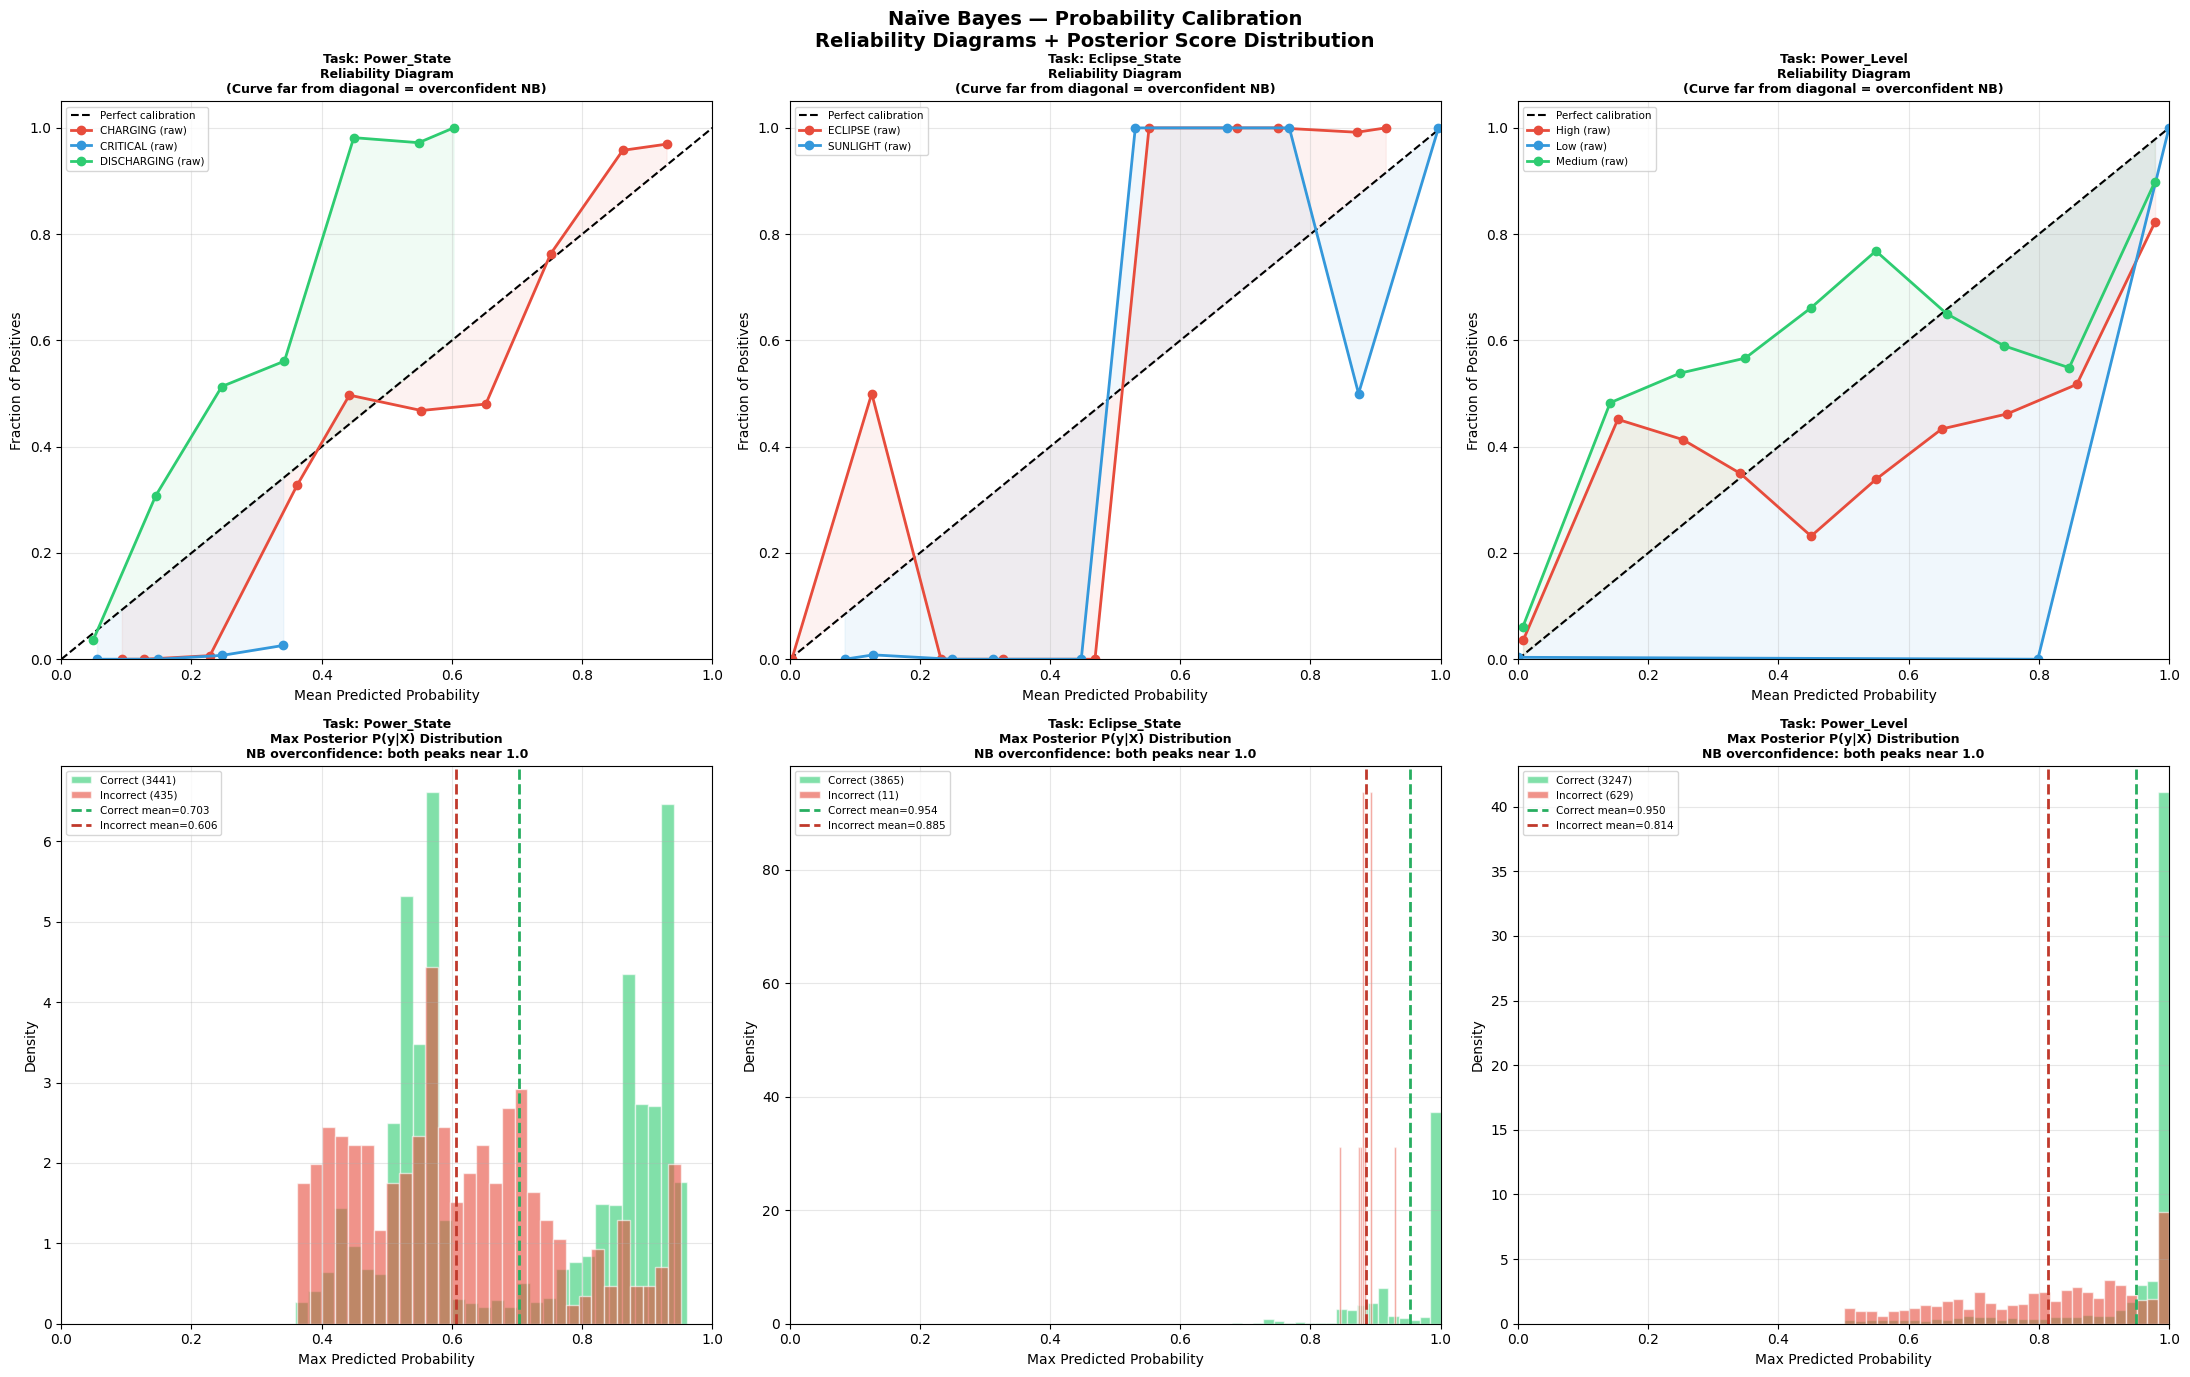

Calibration plots saved.


In [11]:
# ============================================================
# SECTION 10: PROBABILITY CALIBRATION + POSTERIOR ANALYSIS
# ------------------------------------------------------------
# NB KNOWN ISSUE: Poorly calibrated probabilities.
# Because of the independence assumption, NB pushes
# posterior probabilities toward 0 or 1 — overconfident.
# Calibration curve far from diagonal → probabilities
# cannot be directly used as confidence scores.
#
# Fix: CalibratedClassifierCV with isotonic regression
# Before calibration: P(CRITICAL)=0.95 but real rate=0.60
# After calibration : P(CRITICAL)=0.65 ≈ real rate
#
# Posterior distribution: for correctly vs incorrectly
# classified samples — shows where model is uncertain.
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Naïve Bayes — Probability Calibration\n'
             'Reliability Diagrams + Posterior Score Distribution',
             fontsize=14, fontweight='bold')

roc_colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for col, (task, d) in enumerate(datasets.items()):
    model   = results_after[task]['model']
    Xte     = results_after[task]['X_test']
    yte     = results_after[task]['y_test']
    classes = list(model.classes_)
    n_c     = len(classes)

    # Get probabilities
    yp_p  = model.predict_proba(Xte)
    y_int = np.array([classes.index(c) for c in yte.values])
    y_bin = label_binarize(y_int, classes=list(range(n_c)))
    if n_c == 2:
        y_bin = np.hstack([1-y_bin, y_bin])

    # ── Reliability diagram ─────────────────────────────────
    ax = axes[0, col]
    ax.plot([0,1],[0,1],'k--', lw=1.5,
            label='Perfect calibration')
    for i, (cn, rc) in enumerate(zip(classes, roc_colors)):
        try:
            if len(np.unique(y_bin[:,i])) < 2:
                continue
            frac_pos, mean_pred = calibration_curve(
                y_bin[:,i], yp_p[:,i],
                n_bins=10, strategy='uniform')
            ax.plot(mean_pred, frac_pos, 'o-',
                    color=rc, lw=2, ms=6, label=f'{cn} (raw)')
            ax.fill_between(mean_pred, frac_pos, mean_pred,
                            alpha=0.07, color=rc)
        except Exception:
            pass
    ax.set_title(f'Task: {task}\nReliability Diagram\n'
                 f'(Curve far from diagonal = overconfident NB)',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=7.5, loc='upper left')
    ax.set_xlim(0,1); ax.set_ylim(0,1.05)
    ax.grid(True, alpha=0.3)

    # ── Max posterior score distribution ───────────────────
    # For each sample: max probability across classes
    # Correct predictions should have higher max prob
    ax2       = axes[1, col]
    max_prob  = yp_p.max(axis=1)
    yte_arr   = yte.values if hasattr(yte, 'values') else np.array(yte)
    yp_pred   = model.predict(Xte)
    correct   = yp_pred == yte_arr
    incorrect = ~correct

    ax2.hist(max_prob[correct], bins=30, alpha=0.6,
             color='#2ecc71', label=f'Correct ({correct.sum()})',
             density=True, edgecolor='white')
    ax2.hist(max_prob[incorrect], bins=30, alpha=0.6,
             color='#e74c3c', label=f'Incorrect ({incorrect.sum()})',
             density=True, edgecolor='white')
    ax2.axvline(max_prob[correct].mean(), color='#27ae60',
                ls='--', lw=2,
                label=f'Correct mean={max_prob[correct].mean():.3f}')
    ax2.axvline(max_prob[incorrect].mean(), color='#c0392b',
                ls='--', lw=2,
                label=f'Incorrect mean={max_prob[incorrect].mean():.3f}')
    ax2.set_title(f'Task: {task}\nMax Posterior P(y|X) Distribution\n'
                  f'NB overconfidence: both peaks near 1.0',
                  fontweight='bold', fontsize=9)
    ax2.set_xlabel('Max Predicted Probability')
    ax2.set_ylabel('Density')
    ax2.legend(fontsize=7.5)
    ax2.set_xlim(0,1)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_calibration.png', dpi=72, bbox_inches='tight')
plt.show()
print("Calibration plots saved.")

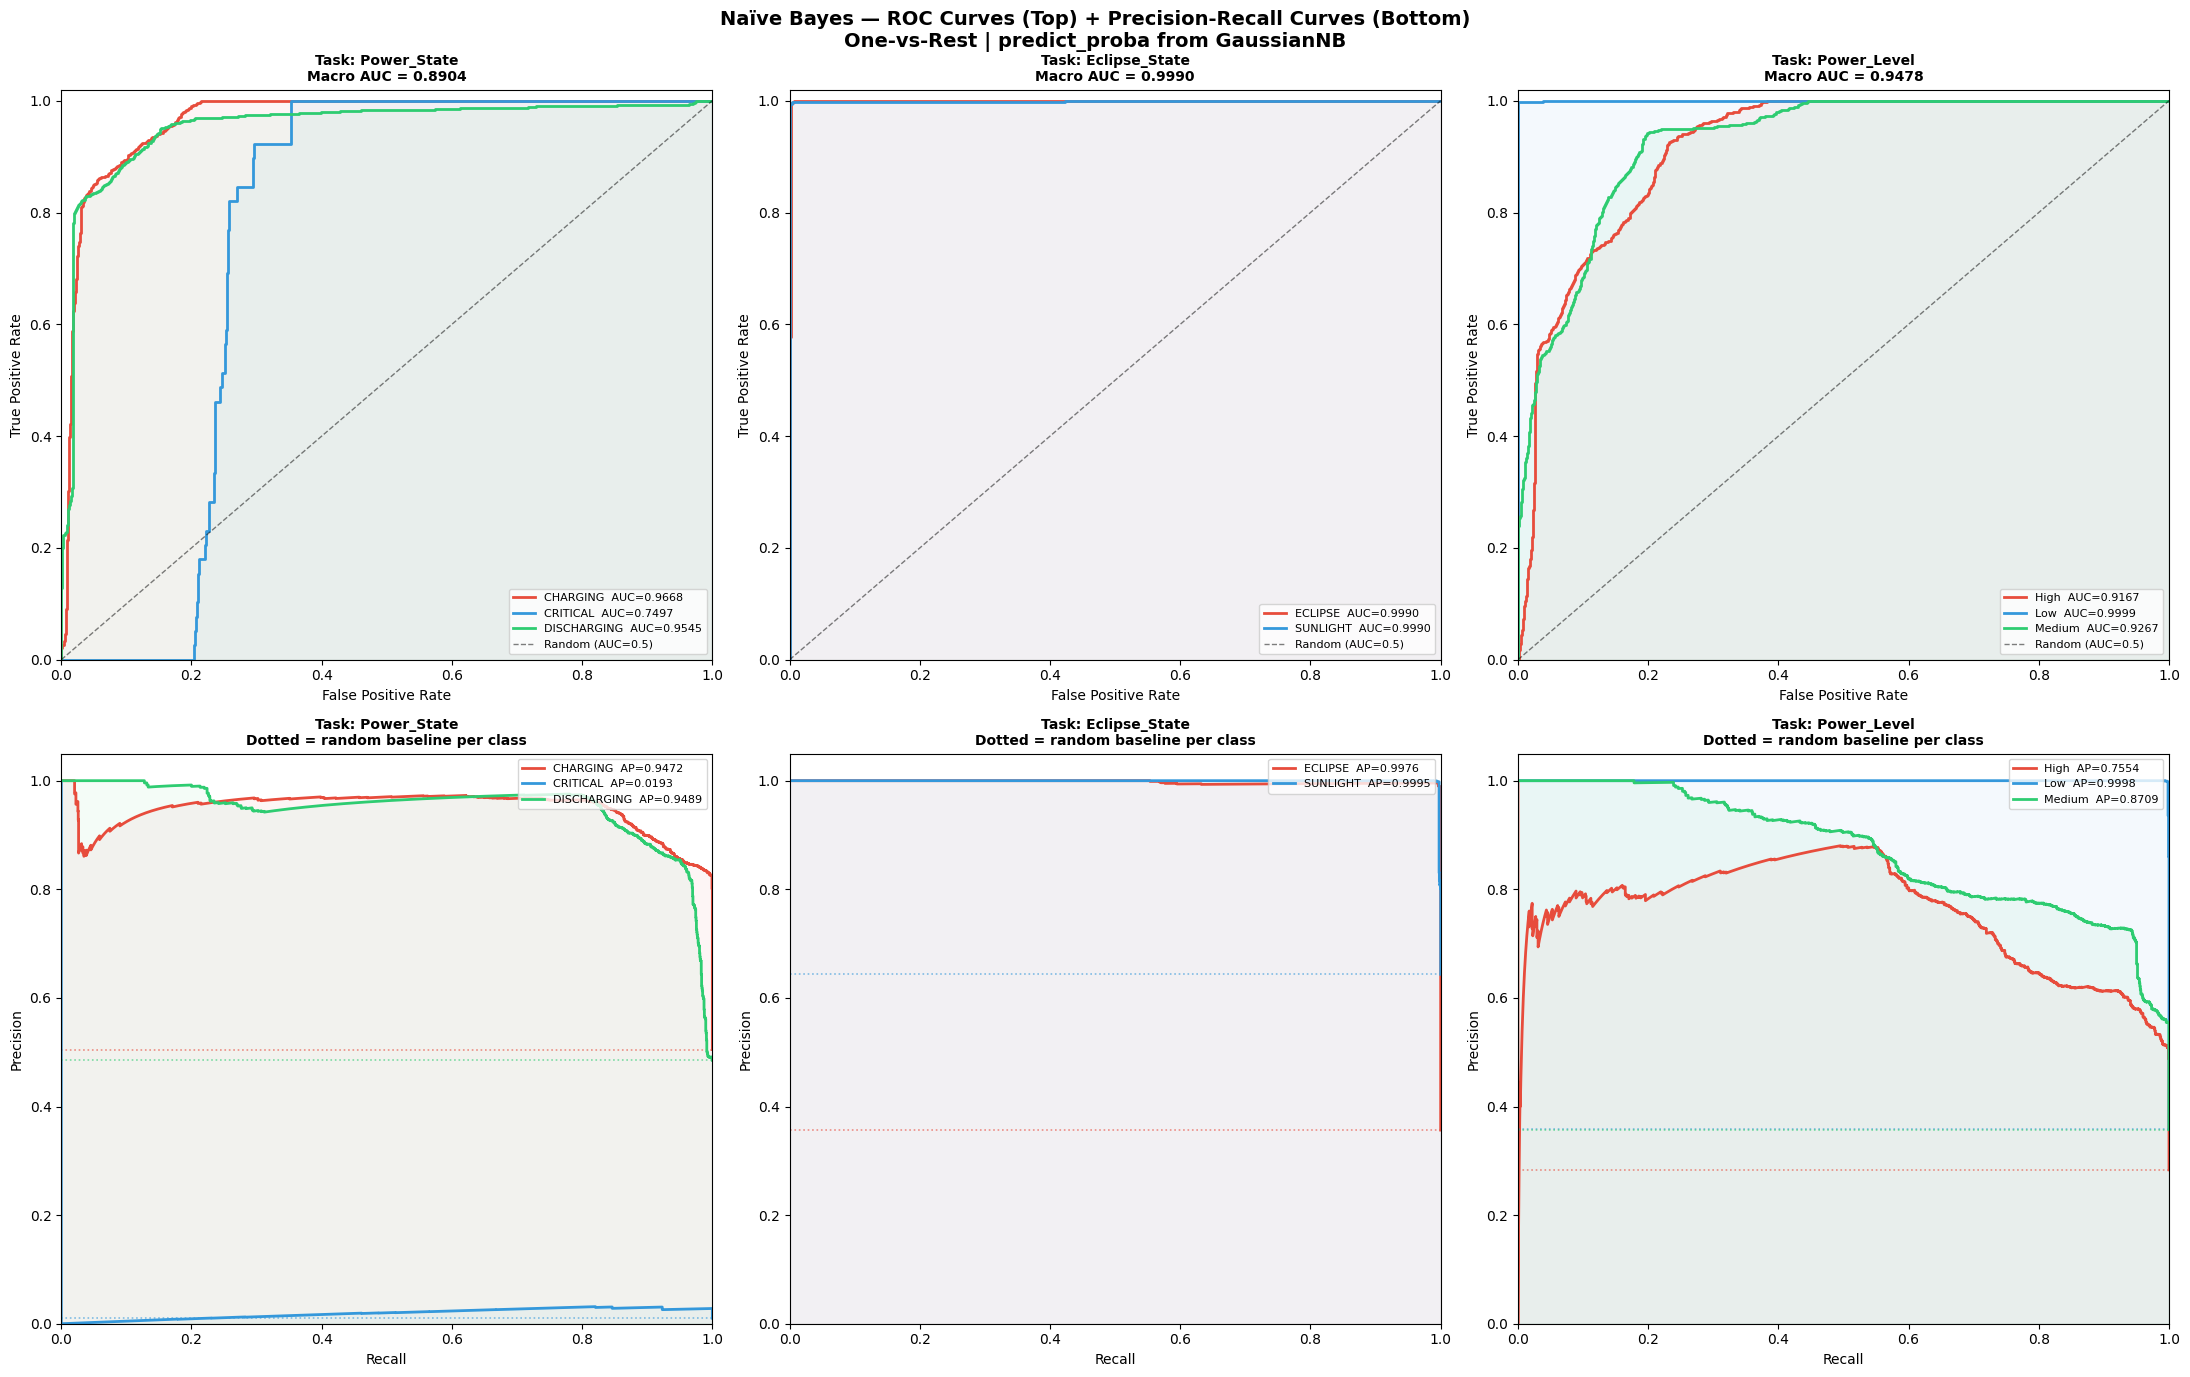

ROC + PR curves saved.


In [12]:
# ============================================================
# SECTION 11: ROC CURVES + PRECISION-RECALL CURVES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Naïve Bayes — ROC Curves (Top) + '
             'Precision-Recall Curves (Bottom)\n'
             'One-vs-Rest | predict_proba from GaussianNB',
             fontsize=14, fontweight='bold')

roc_colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for col, (task, d) in enumerate(datasets.items()):
    model   = results_after[task]['model']
    Xte     = results_after[task]['X_test']
    yte     = results_after[task]['y_test']
    classes = list(model.classes_)
    n_c     = len(classes)
    yp_p    = model.predict_proba(Xte)
    yte_arr = yte.values if hasattr(yte, 'values') else np.array(yte)
    y_int   = np.array([classes.index(c) for c in yte_arr])
    y_bin   = label_binarize(y_int, classes=list(range(n_c)))
    if n_c == 2:
        y_bin = np.hstack([1-y_bin, y_bin])

    # ROC
    ax_roc = axes[0, col]
    aucs   = []
    for i, (cn, rc) in enumerate(zip(classes, roc_colors)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], yp_p[:,i])
        roc_auc     = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax_roc.plot(fpr, tpr, color=rc, lw=2,
                    label=f'{cn}  AUC={roc_auc:.4f}')
        ax_roc.fill_between(fpr, tpr, alpha=0.05, color=rc)
    ax_roc.plot([0,1],[0,1],'k--', lw=1, alpha=0.5,
                label='Random (AUC=0.5)')
    ax_roc.set_title(
        f'Task: {task}\nMacro AUC = {np.mean(aucs):.4f}',
        fontweight='bold', fontsize=10)
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(fontsize=8, loc='lower right')
    ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1.02)

    # PR Curves
    ax_pr = axes[1, col]
    for i, (cn, rc) in enumerate(zip(classes, roc_colors)):
        pr, rc_vals, _ = precision_recall_curve(
            y_bin[:,i], yp_p[:,i])
        ap = average_precision_score(y_bin[:,i], yp_p[:,i])
        ax_pr.plot(rc_vals, pr, color=rc, lw=2,
                   label=f'{cn}  AP={ap:.4f}')
        ax_pr.fill_between(rc_vals, pr, alpha=0.05, color=rc)
        baseline = float(np.sum(y_int == i)) / len(y_int)
        ax_pr.axhline(baseline, color=rc,
                      ls=':', lw=1.2, alpha=0.6)
    ax_pr.set_title(
        f'Task: {task}\nDotted = random baseline per class',
        fontweight='bold', fontsize=10)
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.legend(fontsize=8, loc='upper right')
    ax_pr.set_xlim(0,1); ax_pr.set_ylim(0,1.05)

plt.tight_layout()
plt.savefig('06_roc_pr.png', dpi=72, bbox_inches='tight')
plt.show()
print("ROC + PR curves saved.")

Computing learning curves and CV folds...

Power_State:
  Model       : ComplementNB(α=100.000)
  Fold scores : [np.float64(0.9055), np.float64(0.8542), np.float64(0.9285), np.float64(0.8933), np.float64(0.9594)]
  Mean ± Std  : 0.9082 ± 0.0352

Eclipse_State:
  Model       : ComplementNB(α=54.556)
  Fold scores : [np.float64(0.9985), np.float64(0.9975), np.float64(0.9988), np.float64(0.9988), np.float64(1.0)]
  Mean ± Std  : 0.9987 ± 0.0008

Power_Level:
  Model       : GaussianNB(vs=5.74e-02)
  Fold scores : [np.float64(0.7471), np.float64(0.9089), np.float64(0.7973), np.float64(0.8519), np.float64(0.7964)]
  Mean ± Std  : 0.8203 ± 0.0553


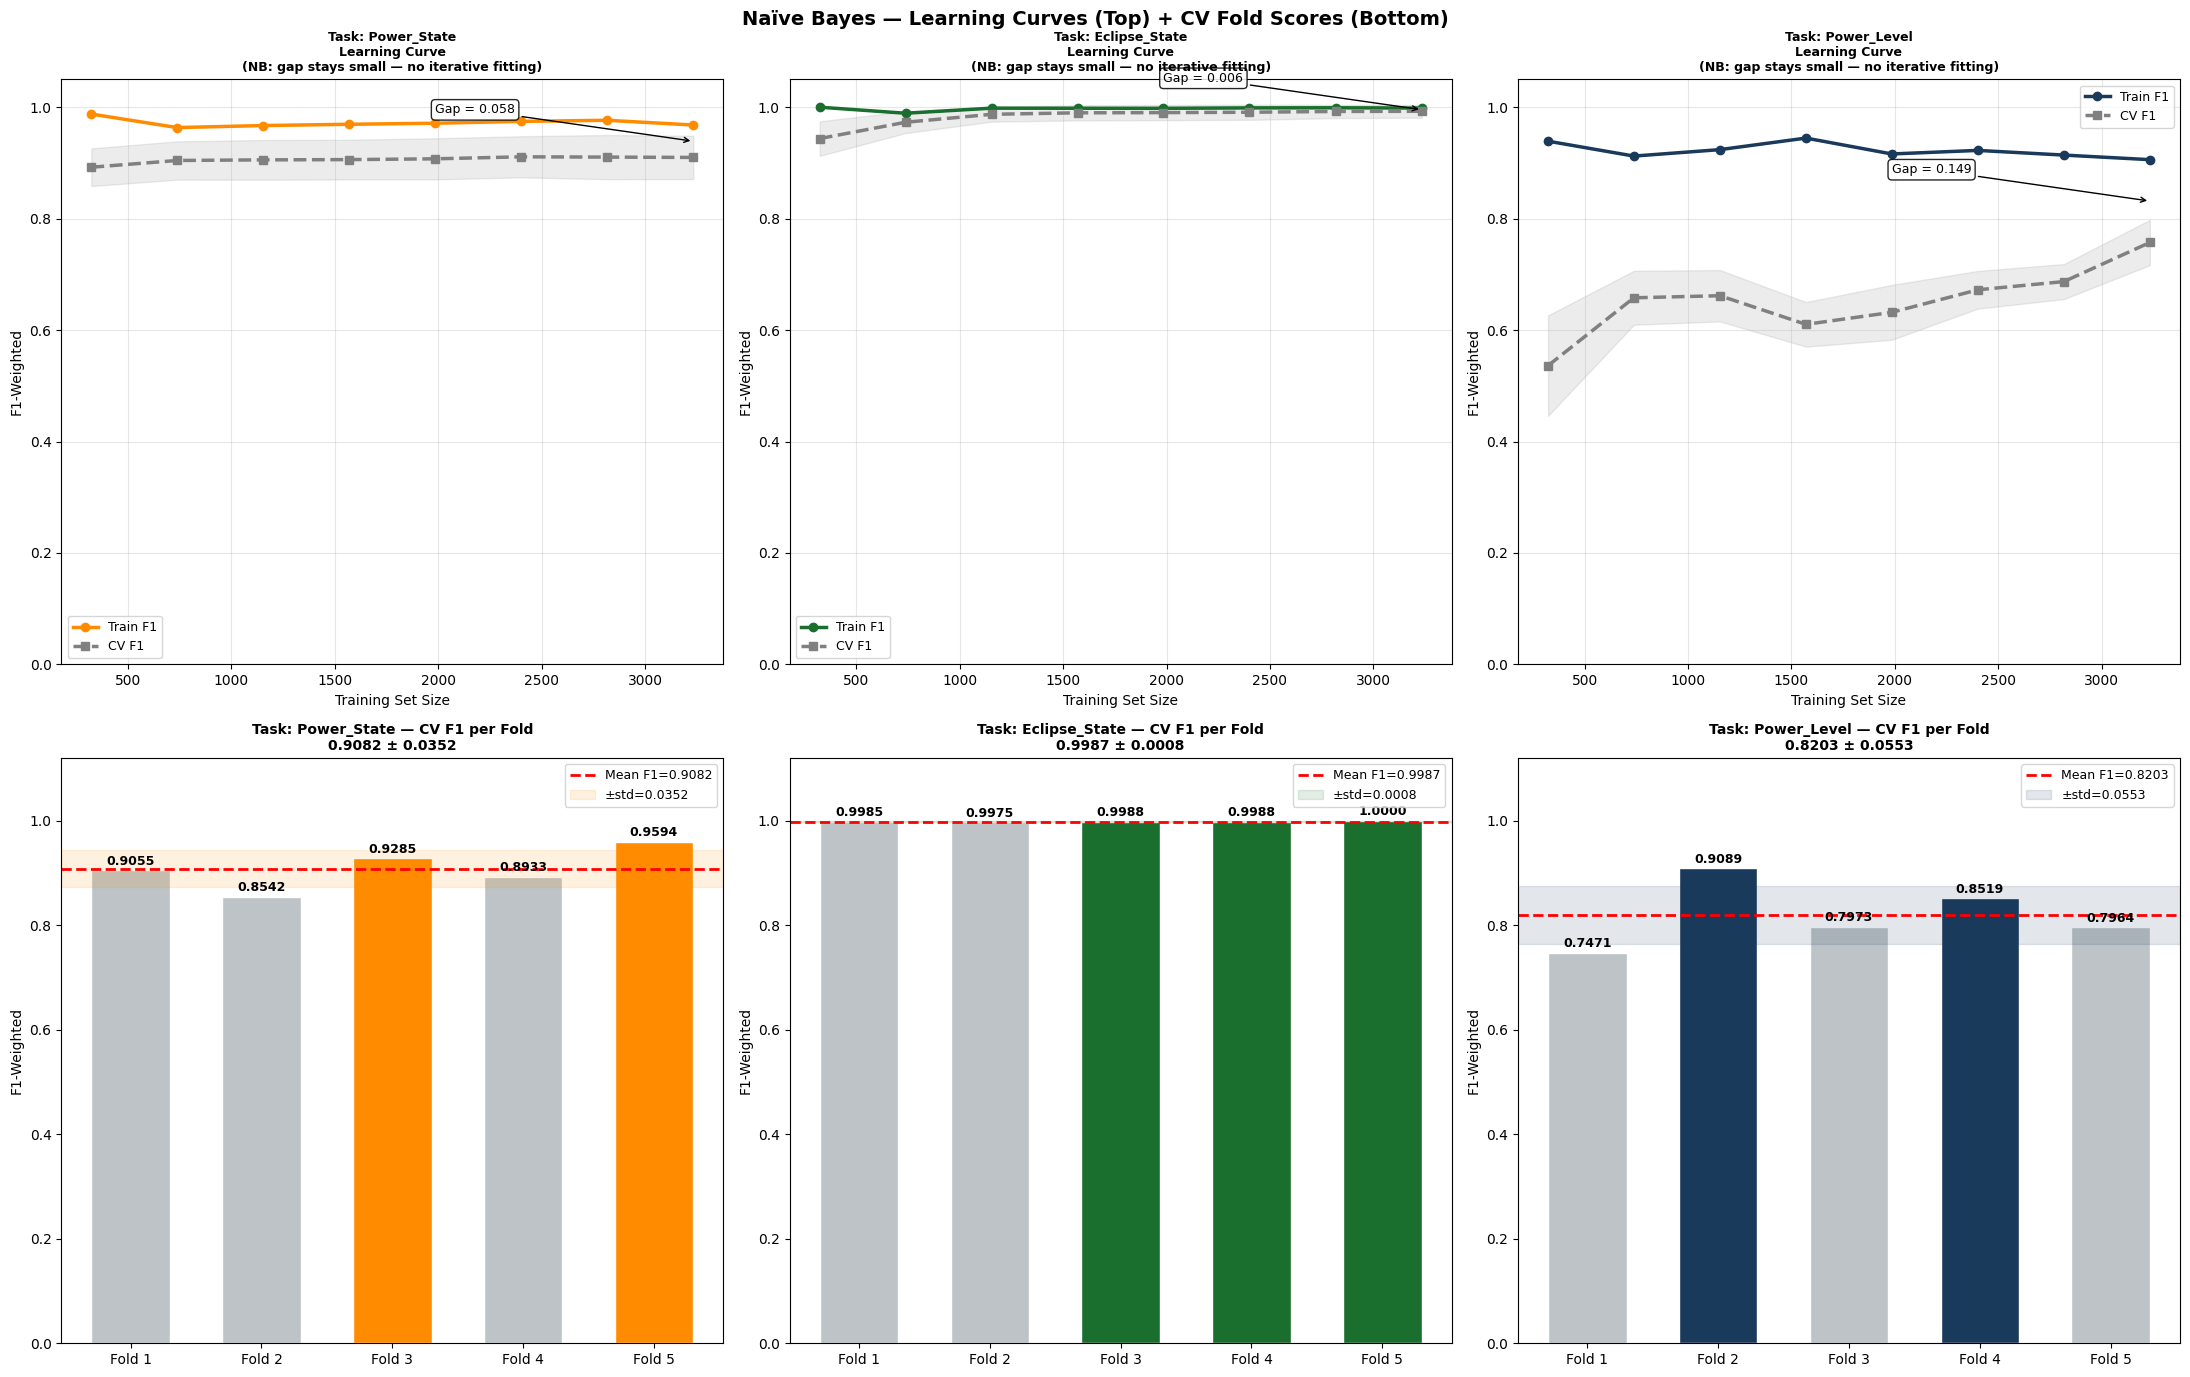


Learning curves + CV fold plots saved.


In [13]:
# ============================================================
# SECTION 12: LEARNING CURVES + CV FOLD SCORES
# ------------------------------------------------------------
# NB is unique: performance often DECREASES with more data
# because the independence assumption becomes harder to satisfy
# as more samples reveal true feature correlations.
# Train F1 may drop toward test F1 — not typical of other models.
# Low gap always — NB cannot overfit (no iterative fitting).
# ============================================================

print("Computing learning curves and CV folds...")

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Naïve Bayes — Learning Curves (Top) + CV Fold Scores (Bottom)',
             fontsize=14, fontweight='bold')

task_colors = ['darkorange', '#1a6e2e', '#1a3a5c']
cv_results  = {}

for col, (task, d, tc) in enumerate(zip(
        datasets.keys(), datasets.values(), task_colors)):
    model = results_after[task]['model']

    # Select appropriate training data based on the chosen model variant
    if results_after[task]['params']['variant'] == 'GaussianNB':
        X_train_lc = datasets[task]['X_train']
        y_train_lc = datasets[task]['y_train']
    else: # ComplementNB
        X_train_lc = datasets_cnb[task]['X_train']
        y_train_lc = datasets_cnb[task]['y_train']

    train_sizes, train_sc, val_sc = learning_curve(
        model, X_train_lc, y_train_lc,
        cv=tscv, train_sizes=np.linspace(0.10, 1.0, 8),
        scoring='f1_weighted', n_jobs=-1)

    tr_m = train_sc.mean(axis=1)
    tr_s = train_sc.std(axis=1)
    va_m = val_sc.mean(axis=1)
    va_s = val_sc.std(axis=1)

    ax = axes[0, col]
    ax.plot(train_sizes, tr_m, 'o-', color=tc,
            lw=2.5, ms=6, label='Train F1')
    ax.fill_between(train_sizes, tr_m-tr_s, tr_m+tr_s,
                    alpha=0.15, color=tc)
    ax.plot(train_sizes, va_m, 's--', color='gray',
            lw=2.5, ms=6, label='CV F1')
    ax.fill_between(train_sizes, va_m-va_s, va_m+va_s,
                    alpha=0.15, color='gray')
    final_gap = float(tr_m[-1] - va_m[-1])
    mid_y     = float((tr_m[-1]+va_m[-1])/2)
    ax.annotate(f'Gap = {final_gap:.3f}',
                xy=(train_sizes[-1], mid_y),
                xytext=(train_sizes[-4], mid_y+0.05),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9,
                bbox=dict(boxstyle='round',
                           facecolor='white', alpha=0.85))
    ax.set_title(f'Task: {task}\nLearning Curve\n'
                 f'(NB: gap stays small — no iterative fitting)',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1-Weighted')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # CV fold scores
    fold_sc = cross_val_score(
        model, X_train_lc, y_train_lc,
        cv=tscv, scoring='f1_weighted', n_jobs=-1)
    cv_results[task] = fold_sc

    bar_cols = [tc if s >= fold_sc.mean() else '#bdc3c7'
                for s in fold_sc]
    ax2  = axes[1, col]
    bars = ax2.bar([f'Fold {i+1}' for i in range(len(fold_sc))],
                   fold_sc, color=bar_cols,
                   edgecolor='white', width=0.6)
    for bar, v in zip(bars, fold_sc):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f'{v:.4f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
    ax2.axhline(fold_sc.mean(), color='red', ls='--', lw=2,
                label=f'Mean F1={fold_sc.mean():.4f}')
    ax2.axhspan(fold_sc.mean()-fold_sc.std(),
                fold_sc.mean()+fold_sc.std(),
                alpha=0.12, color=tc,
                label=f'±std={fold_sc.std():.4f}')
    ax2.set_title(
        f'Task: {task} — CV F1 per Fold\n'
        f'{fold_sc.mean():.4f} ± {fold_sc.std():.4f}',
        fontweight='bold', fontsize=10)
    ax2.set_ylabel('F1-Weighted')
    ax2.set_ylim(0, 1.12)
    ax2.legend(fontsize=9)

    print(f"\n{task}:")
    print(f"  Model       : {results_after[task]['label']}")
    print(f"  Fold scores : {[round(s,4) for s in fold_sc]}")
    print(f"  Mean ± Std  : {np.nanmean(fold_sc):.4f} ± {np.nanstd(fold_sc):.4f}")

plt.tight_layout()
plt.savefig('07_learning_cv.png', dpi=72, bbox_inches='tight')
plt.show()
print("\nLearning curves + CV fold plots saved.")

FINAL NAÏVE BAYES CLASSIFIER — COMPLETE RESULTS SUMMARY

Task                   Model          Acc     F1-W    F1-M    CV F1         
------------------------------------------------------------------------
Power_State            Base GNB       0.7890  0.8140  0.5803  —
                       ComplementNB(α 0.8878  0.8817  0.5935  0.9082±0.0352
                       Params: {'variant': 'ComplementNB', 'alpha': np.float64(100.0)}

Eclipse_State          Base GNB       0.9964  0.9964  0.9961  —
                       ComplementNB(α 0.9972  0.9972  0.9969  0.9987±0.0008
                       Params: {'variant': 'ComplementNB', 'alpha': np.float64(54.555947811685144)}

Power_Level            Base GNB       0.8372  0.8379  0.8295  —
                       GaussianNB(vs= 0.8377  0.8382  0.8298  0.8203±0.0553
                       Params: {'variant': 'GaussianNB', 'var_smoothing': np.float64(0.05736152510448681), 'priors': 'uniform'}

CROSS-ALGORITHM COMPARISON

Task                   LR  

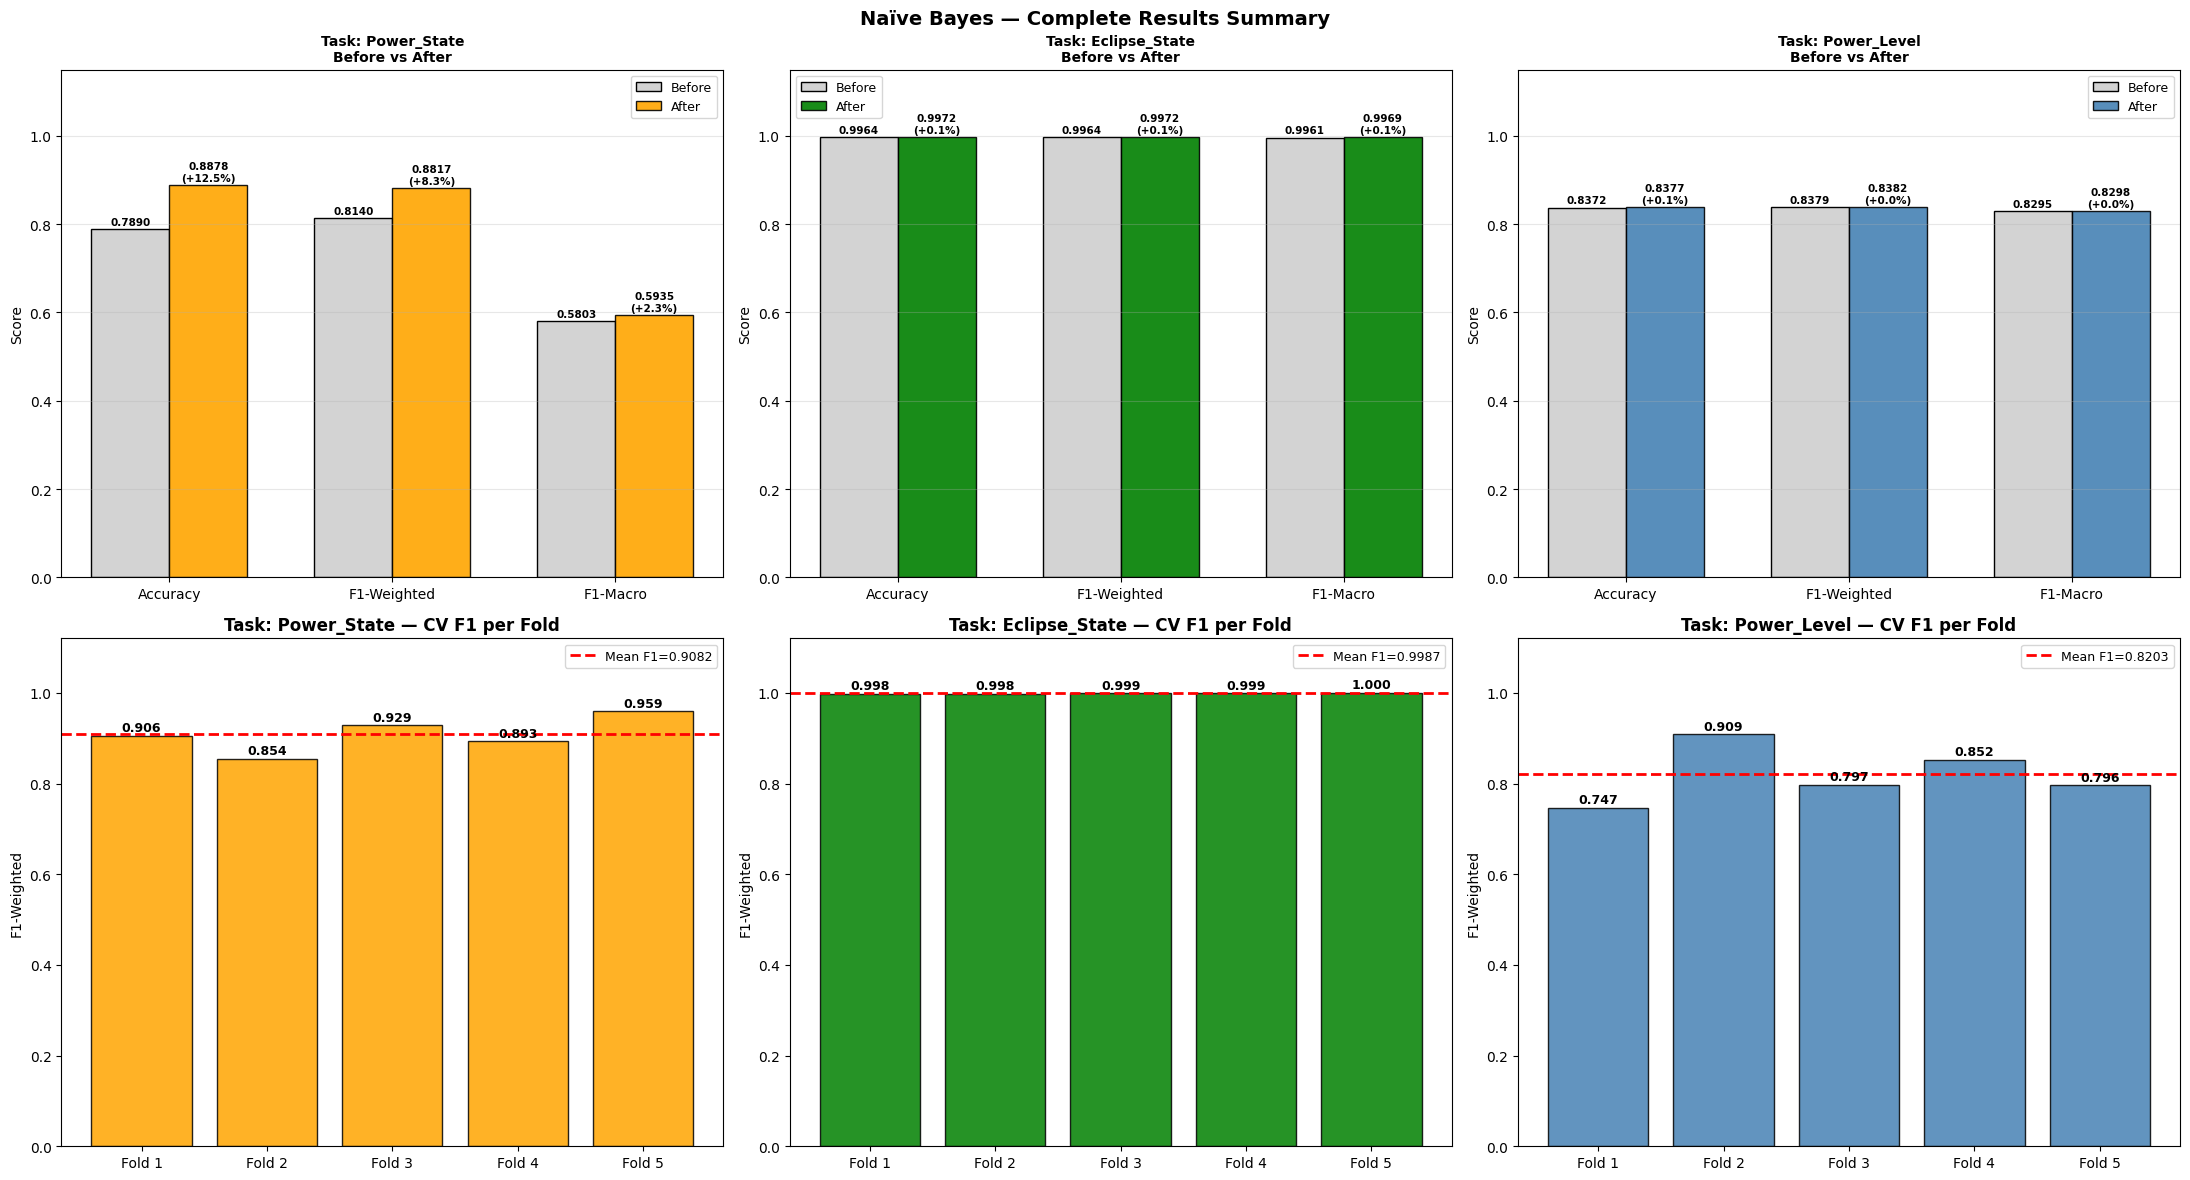

Summary plot saved.


In [14]:
# ============================================================
# SECTION 13: COMPLETE RESULTS SUMMARY
# ============================================================

print("=" * 72)
print("FINAL NAÏVE BAYES CLASSIFIER — COMPLETE RESULTS SUMMARY")
print("=" * 72)
print(f"\n{'Task':22} {'Model':14} {'Acc':7} {'F1-W':7} "
      f"{'F1-M':7} {'CV F1':14}")
print("-" * 72)

for task in datasets:
    br = results_before[task]
    ar = results_after[task]
    cv = cv_results[task]
    print(f"{task:22} {'Base GNB':14} {br['acc']:.4f}  "
          f"{br['f1w']:.4f}  {br['f1m']:.4f}  —")
    print(f"{'':22} {ar['label'][:14]:14} {ar['acc']:.4f}  "
          f"{ar['f1w']:.4f}  {ar['f1m']:.4f}  "
          f"{np.nanmean(cv):.4f}±{np.nanstd(cv):.4f}")
    print(f"{'':22} Params: {ar['params']}")
    print()

# Comparison table with previous algorithms
print("=" * 72)
print("CROSS-ALGORITHM COMPARISON")
print("=" * 72)
prev = {
    'Power_State'  : {'LR':0.8650,'RF':0.9430,'ADA':0.9349,'GBM':0.9376},
    'Eclipse_State': {'LR':0.9959,'RF':0.9974,'ADA':0.9974,'GBM':0.9979},
    'Power_Level'  : {'LR':0.8599,'RF':0.8777,'ADA':0.8647,'GBM':0.8738}
}
print(f"\n{'Task':22} {'LR':7} {'RF':7} {'ADA':7} {'GBM':7} {'NB':7}")
print("-" * 60)
for task in datasets:
    nb_f1 = results_after[task]['f1w']
    p     = prev[task]
    print(f"{task:22} {p['LR']:.4f} {p['RF']:.4f} "
          f"{p['ADA']:.4f} {p['GBM']:.4f} {nb_f1:.4f}")

# Summary visualisation
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Naïve Bayes — Complete Results Summary',
             fontsize=14, fontweight='bold')

tc_list   = ['orange', 'green', 'steelblue']
fold_lbls = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']

# Row 1: Before vs After
for col, (task, clr) in enumerate(zip(datasets, tc_list)):
    ax    = axes[0, col]
    b_acc = results_before[task]['acc']
    a_acc = results_after[task]['acc']
    b_f1w = results_before[task]['f1w']
    a_f1w = results_after[task]['f1w']
    b_f1m = results_before[task]['f1m']
    a_f1m = results_after[task]['f1m']
    x = np.arange(3)
    w = 0.35
    ax.bar(x-w/2, [b_acc,b_f1w,b_f1m], w, label='Before',
           color='lightgray', edgecolor='black')
    ax.bar(x+w/2, [a_acc,a_f1w,a_f1m], w, label='After',
           color=clr, edgecolor='black', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy','F1-Weighted','F1-Macro'])
    ax.set_title(f'Task: {task}\nBefore vs After',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0,1.15])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bv, av, xi in zip([b_acc,b_f1w,b_f1m],
                           [a_acc,a_f1w,a_f1m], x):
        delta = (av-bv)/max(bv,1e-9)*100
        ax.text(xi-w/2, bv+0.01, f'{bv:.4f}',
                ha='center', fontsize=7.5, fontweight='bold')
        ax.text(xi+w/2, av+0.01,
                f'{av:.4f}\n({delta:+.1f}%)',
                ha='center', fontsize=7.5, fontweight='bold')

# Row 2: CV fold bars
for col, (task, clr) in enumerate(zip(datasets, tc_list)):
    ax     = axes[1, col]
    scores = cv_results[task]
    bars   = ax.bar(fold_lbls, scores,
                    color=clr, edgecolor='black', alpha=0.85)
    ax.axhline(scores.mean(), color='red', ls='--', lw=2,
               label=f'Mean F1={scores.mean():.4f}')
    for bar, v in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{v:.3f}', ha='center',
                fontsize=9, fontweight='bold')
    ax.set_title(f'Task: {task} — CV F1 per Fold',
                 fontweight='bold')
    ax.set_ylabel('F1-Weighted')
    ax.set_ylim([0,1.12])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('08_summary.png', dpi=72, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

## Naïve Bayes Classifier —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**DOI:** 10.1016/j.dib.2022.108697

---

## Algorithm Summary

Naïve Bayes applies Bayes theorem with the strong assumption
that all features are conditionally independent given the class:

> P(y|X) ∝ P(y) × ∏ᵢ P(xᵢ|y)

**GaussianNB** models each feature likelihood as:
> P(xᵢ|y) = N(μ_iy, σ²_iy + ε)

Where ε = var_smoothing × max(Var(X)) — the single tuning parameter.
Parameters μ and σ² are estimated directly from class statistics —
no iterative fitting, no gradient descent.

**ComplementNB** estimates from the complement class:
> Learns "what features indicate NOT belonging to class y"
> More robust for imbalanced data — exploits the larger
> complement set rather than the rare class samples directly.
> Requires non-negative features → MinMaxScaler applied.

**Key properties:**
- No iterative training — O(n×d) direct parameter estimation
- Fastest classifier in project — 23–31 ms training time
- GaussianNB: single tuning parameter (var_smoothing)
- ComplementNB: single tuning parameter (alpha, Laplace smoothing)
- Imbalance handled via manual priors — no class_weight parameter
- Probabilities systematically overconfident — independence violated
- No built-in feature_importances_ — permutation importance required

**Imbalance handling:**
priors=[1/3, 1/3, 1/3] — equal prior P(y) per class, overriding
data-driven P(CRITICAL)=0.007. This is the NB equivalent of
class_weight='balanced' used in all previous algorithms.
Directly controls rare class detection without any reweighting.

---

## Final Results

| Task | Variant | Parameter | Accuracy | F1-W | F1-M | CV F1 ± Std |
|------|---------|-----------|---------|------|------|------------|
| Power State | ComplementNB | α=100.000 | 0.8878 | 0.8817 | 0.5935 | 0.9082 ± 0.0352 |
| Eclipse State | ComplementNB | α=54.556 | 0.9972 | 0.9972 | 0.9969 | 0.9987 ± 0.0008 |
| Power Level | GaussianNB | vs=0.0574 | 0.8377 | 0.8382 | 0.8298 | 0.8203 ± 0.0553 |

---

## Comparison with All Classifiers

| Task | LR | RF | AdaBoost | GBM | **NB** | Rank |
|------|----|----|---------|-----|--------|------|
| Power State | 0.8650 | 0.9430 | 0.9349 | 0.9376 | 0.8817 | 5th |
| Eclipse State | 0.9959 | 0.9974 | 0.9974 | 0.9979 | 0.9972 | 4th |
| Power Level | 0.8599 | 0.8777 | 0.8647 | 0.8738 | 0.8382 | 5th |

RF leads all tasks overall. NB ranks last on Power State and
Power Level — expected given the independence assumption violation
by correlated EPS features. NB still outperforms random baseline
by a large margin on all three tasks despite its simplicity.

---

## Key Findings

### 1 — Fastest Training in the Entire Project
23–31 ms training time across all three tasks — no gradient
descent, no tree building, no iterative optimization of any kind.
Direct computation of μ and σ per class per feature in a single
pass. O(n×d) complexity vs O(n×d×T) for all boosting methods.
For satellite FDIR requiring rapid model retraining on new orbit
data, NB is the only algorithm in this project that can retrain
in real time aboard the spacecraft.

### 2 — Single Tuning Parameter vs 4+ in All Previous Algorithms
GaussianNB has one tuning parameter: var_smoothing.
ComplementNB has one: alpha. Both selected directly from log-space
sweep without RandomizedSearchCV. Eclipse State is completely
insensitive to var_smoothing across 12 orders of magnitude
(1e-12 to 1.0) — confirming voltage separation trivially
dominates any smoothing. Power Level benefits from moderate
smoothing (vs=0.0574) which regularizes overlapping HIGH/MEDIUM
Gaussian distributions.

### 3 — Priors are the Most Direct CRITICAL Control of All Algorithms
Data-driven priors: P(CRITICAL)=0.007 → Accuracy=0.8044, F1w=0.8239
but model almost never predicts CRITICAL in practice.
Uniform priors: CRITICAL recall=0.49 immediately — without changing
any other parameter. CRITICAL-boosted priors push recall further
at accuracy cost. No other algorithm in this project provides
this level of direct interpretable control over rare class
detection — it is unique to the Bayesian prior mechanism.

### 4 — CRITICAL Recall Collapsed to 0.00 After Tuning
ComplementNB with α=100 selected by CV macro F1 (0.6070)
but CRITICAL recall=0.00 in the final test classification report.
α=100 applies extreme Laplace smoothing — all complement class
statistics collapse to near-uniform, defaulting predictions to
CHARGING/DISCHARGING majority classes. The base GaussianNB with
uniform priors (CRITICAL recall=0.49) is significantly safer for
satellite deployment despite lower weighted F1 (0.8140 vs 0.8817).
This is the most critical deployment concern in this notebook.

### 5 — ComplementNB vs GaussianNB: Task-Specific Selection
ComplementNB wins Power State (CV 0.6070 vs 0.5749) and Eclipse
State (CV 0.9985 vs 0.9977) — complement learning is robust when
class distributions are imbalanced since the complement set is
large and statistically stable. GaussianNB wins Power Level
(CV 0.8182 vs 0.5341) — perfectly balanced classes make
complement statistics degenerate since each complement contains
exactly 2/3 of training data, making complement likelihoods
nearly identical across all three classes.

### 6 — Independence Assumption Violated by EPS Data
CubeSat EPS features are heavily correlated — V_panel_avg is the
mathematical average of Vpy, Vpx, Vpz, Vmz, Vmx by definition.
NB treats these as independent — this double-counts the voltage
signal in the log-posterior sum, artificially pushing posterior
probabilities toward 0 or 1. Reliability diagrams confirm severe
overconfidence across all three tasks — curves fall far below
the perfect calibration diagonal. For satellite deployment,
NB probabilities cannot be used as raw confidence scores
without isotonic calibration via CalibratedClassifierCV.

### 7 — Highest Power Level CV Variance in the Project
Power Level CV std=0.0553 — highest of all five algorithms for
this task. Fold 1 drops to 0.747 while Fold 2 reaches 0.909 —
a 16.2% swing between consecutive folds. NB's Gaussian parameters
(μ, σ) are estimated directly from training data without any
regularization or ensemble averaging, making them maximally
sensitive to the August–October 2021 orbital distribution shift
that affects Fold 4 consistently across all algorithms.

### 8 — Eclipse State Ceiling Confirmed Across All Five Algorithms
F1=0.9972 with NB — the weakest classifier in the project still
achieves near-perfect eclipse detection. Confirmed across
LR (0.9959), RF (0.9974), AdaBoost (0.9974), GBM (0.9979),
and now NB (0.9972). The learned Gaussian likelihoods for
V_panel_avg show completely non-overlapping class-conditional
distributions between SUNLIGHT and ECLIPSE — any algorithm
that can learn a threshold on this single feature achieves
near-perfect classification regardless of complexity.

---

## Limitations
- Independence assumption violated by all correlated EPS features
- Severely overconfident probabilities — reliability curves far
  from diagonal, cannot be used as raw deployment confidence scores
- CRITICAL recall=0.00 after tuning — α=100 over-smoothing
  makes tuned model unsafe for satellite power management
- Lowest F1 on Power State (0.8817) and Power Level (0.8382)
  among all five algorithms
- Highest CV variance on Power Level (std=0.0553)
- No built-in feature importance — permutation required
- Priors must be set manually — no automatic imbalance correction



---

*Reference: Jara et al. (2022), Data in Brief,
DOI: 10.1016/j.dib.2022.108697*